# PHẦN 2. PHÂN TÍCH PHÂN PHỐI XÁC SUẤT

## Bối cảnh và mục tiêu

Nhu cầu thuê xe theo giờ biến động theo thời điểm trong ngày, loại ngày và điều kiện thời tiết. Phần này tiếp nối kết quả EDA để trả lời câu hỏi: dữ liệu quan sát có hình dạng phân phối nào, và phân phối lý thuyết nào có thể mô tả dữ liệu một cách hợp lý?

Notebook sử dụng dữ liệu đã được xử lý ở Phần 1, nhưng không thay đổi dataset gốc. Các giá trị thời tiết `temp` và `hum` được giữ ở thang chuẩn hóa 0–1. Tổng lượt thuê `cnt` được xem là biến đếm; `casual` và `registered` chỉ được dùng để kiểm tra tính nhất quán, không dùng làm biến giải thích cho mô hình dự báo.

## Câu hỏi nghiên cứu

1. `cnt` có lệch phải, đuôi dài và over-dispersion hay không?
2. Poisson, Negative Binomial, Normal hay Log-normal mô tả `cnt` tốt hơn theo đồ thị và AIC/BIC?
3. `temp` và `hum` gần với Normal hay Beta hơn trên miền giá trị chuẩn hóa?
4. Phân phối và mức trung tâm của `cnt` có khác nhau giữa ngày làm việc và ngày nghỉ không?

## Quy trình phân tích

| Bước | Nội dung | Mục đích |
| --- | --- | --- |
| 2.1 | Xác nhận dữ liệu và thống kê mô tả | Kiểm tra đầu vào, độ lệch và độ phân tán |
| 2.2 | Phân phối thực nghiệm của `cnt` | Nhận diện đuôi phải, cực trị và tỷ lệ tích lũy |
| 2.3 | Fit các phân phối cho `cnt` | So sánh mô hình cho biến đếm và baseline liên tục |
| 2.4 | Phân phối `temp`, `hum` | Đối chiếu Normal và Beta |
| 2.5 | Phân tích theo `workingday` | Cung cấp ngữ cảnh cho phần kiểm định giả thuyết |
| 2.6 | Kết luận và bàn giao | Ghi rõ quyết định, hạn chế và lưu ý downstream |

Các kiểm định goodness-of-fit chỉ là bằng chứng bổ sung. Với cỡ mẫu lớn và dữ liệu theo giờ có tự tương quan, không kết luận chỉ dựa trên p-value.

## 2.1. Kiểm tra dữ liệu đầu vào

### Mục tiêu

Trước khi phân tích hình dạng phân phối, cần xác nhận dữ liệu đầu vào đúng phiên bản, có cấu trúc phù hợp và thỏa các ràng buộc cơ bản của bộ dữ liệu. Các bước kiểm tra tập trung vào kích thước và biến của dữ liệu, giá trị thiếu, dòng/cặp khóa trùng, tính nhất quán của `cnt`, các giá trị bằng 0 và phạm vi của những biến được mô tả.

Đầu vào phân tích là `EDA/cleaned_data/hour_cleaned.csv`. Mỗi dòng biểu diễn một giờ có ghi nhận trong dữ liệu thuê xe đạp Capital Bikeshare tại Washington, D.C. Không sử dụng `day.csv` thay cho dữ liệu theo giờ và không chỉnh sửa file dữ liệu nguồn trong quá trình phân tích.

### Phương pháp

Đọc CSV vào một dataframe trong bộ nhớ. Trước khi kiểm tra, xác định xem file có cột index kỹ thuật do quá trình xuất dữ liệu tạo ra hay không; chỉ loại cột đó khỏi dataframe phân tích nếu thực sự tồn tại. Không loại cột dữ liệu chỉ vì tên cột có dạng chỉ mục nếu chưa xác minh đó là metadata kỹ thuật.

Chuyển `dteday` sang kiểu ngày giờ nếu cột chưa có kiểu phù hợp. Sau đó thực hiện các kiểm tra sau:

- Ghi nhận số dòng, số biến và danh sách cột sau khi xử lý index kỹ thuật.
- Đếm ô thiếu và dòng trùng hoàn toàn.
- Kiểm tra các cặp khóa (`dteday`, `hr`) có bị trùng hay không.
- Đối chiếu quan hệ `cnt = casual + registered`.
- Đếm số dòng có `cnt = 0`, xác định min/max của `cnt` và đếm số dòng có `hum = 0`.
- Tính thống kê mô tả trực tiếp từ dataframe đang phân tích; không chép cố định số liệu cũ vào notebook thay cho việc tính lại.

`casual` và `registered` chỉ được dùng để kiểm tra tính nhất quán với `cnt`. Không sử dụng hai biến này làm biến giải thích cho `cnt`, vì chúng là thành phần cấu thành tổng lượt thuê và có thể gây rò rỉ thông tin.

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.optimize import minimize, minimize_scalar
from scipy.special import gammaln, log_ndtr
from scipy.stats import lognorm, nbinom, norm, poisson



# Tìm dữ liệu từ thư mục hiện tại hoặc một trong các thư mục cha.
relative_data_path = Path("EDA") / "cleaned_data" / "hour_cleaned.csv"
search_locations = [Path.cwd(), *Path.cwd().parents]
data_path = next(
    (
        location / relative_data_path
        for location in search_locations
        if (location / relative_data_path).is_file()
    ),
    None,
)

if data_path is None:
    searched_paths = "\n".join(
        str(location / relative_data_path) for location in search_locations
    )
    raise FileNotFoundError(
        "Không tìm thấy EDA/cleaned_data/hour_cleaned.csv. "
        f"Đã kiểm tra các đường dẫn:\n{searched_paths}"
    )

df_raw = pd.read_csv(data_path)

# Loại cột Unnamed do xuất CSV; chỉ loại cột tên index nếu giá trị là
# dãy đánh số tuần tự, để tránh xóa nhầm một biến dữ liệu thật.
unnamed_columns = [
    column
    for column in df_raw.columns
    if re.fullmatch(r"Unnamed:\s*\d+", str(column))
]

technical_index_columns = []
for column in df_raw.columns:
    if str(column).lower() != "index":
        continue

    index_values = pd.to_numeric(df_raw[column], errors="coerce")
    expected_zero_based = pd.Series(range(len(df_raw)), dtype="int64")
    expected_one_based = pd.Series(range(1, len(df_raw) + 1), dtype="int64")

    if index_values.equals(expected_zero_based) or index_values.equals(
        expected_one_based
    ):
        technical_index_columns.append(column)

columns_to_drop = list(dict.fromkeys(unnamed_columns + technical_index_columns))
df = df_raw.drop(columns=columns_to_drop).copy()

if df.empty:
    raise ValueError(f"Dữ liệu đầu vào rỗng: {data_path}")

schema = pd.DataFrame(
    {
        "STT": range(1, len(df.columns) + 1),
        "Tên biến": df.columns,
        "Kiểu dữ liệu": [str(dtype) for dtype in df.dtypes],
    }
)

schema_styled = (
    schema.style
    .format({"STT": "{:,.0f}"})
    .set_caption("Schema dữ liệu sau khi xử lý index kỹ thuật")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "left"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
)

display(schema_styled)

required_columns = {
    "dteday",
    "hr",
    "cnt",
    "casual",
    "registered",
    "hum",
}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(
        "Dữ liệu thiếu các cột bắt buộc: "
        f"{missing_columns}. Các cột hiện có: {df.columns.tolist()}"
    )

# Chuẩn hóa kiểu dữ liệu cần dùng cho kiểm tra.
df["dteday"] = pd.to_datetime(df["dteday"], errors="raise")
for column in ["hr", "cnt", "casual", "registered", "hum"]:
    df[column] = pd.to_numeric(df[column], errors="raise")

# Tính các kết quả kiểm tra từ dữ liệu vừa đọc, không nhập tay số kết quả.
checks = {
    "Số dòng": int(len(df)),
    "Số biến": int(df.shape[1]),
    "Ô thiếu": int(df.isna().sum().sum()),
    "Dòng trùng hoàn toàn": int(df.duplicated().sum()),
    "Cặp (dteday, hr) trùng": int(df.duplicated(["dteday", "hr"]).sum()),
    "Dòng không thỏa cnt = casual + registered": int(
        df["cnt"].ne(df["casual"] + df["registered"]).sum()
    ),
    "Dòng có cnt = 0": int(df["cnt"].eq(0).sum()),
    "cnt nhỏ nhất": float(df["cnt"].min()),
    "cnt lớn nhất": float(df["cnt"].max()),
    "Dòng có hum = 0": int(df["hum"].eq(0).sum()),
}

# Các mốc này dùng làm sanity check theo hợp đồng dữ liệu trong PLAN.md.
baseline = {
    "Số dòng": 17_379,
    "Số biến": 17,
    "Ô thiếu": 0,
    "Dòng trùng hoàn toàn": 0,
    "Cặp (dteday, hr) trùng": 0,
    "Dòng không thỏa cnt = casual + registered": 0,
    "Dòng có cnt = 0": 0,
    "cnt nhỏ nhất": 1.0,
    "cnt lớn nhất": 977.0,
    "Dòng có hum = 0": 0,
}

results = pd.DataFrame(
    [
        {
            "Nội dung kiểm tra": name,
            "Kết quả tính từ dữ liệu": value,
            "Baseline đối chiếu": baseline[name],
            "Khớp baseline": value == baseline[name],
        }
        for name, value in checks.items()
    ]
)

results_display = results.rename(
    columns={
        "Nội dung kiểm tra": "Nội dung kiểm tra",
        "Kết quả tính từ dữ liệu": "Kết quả tính được",
        "Baseline đối chiếu": "Mốc đối chiếu",
        "Khớp baseline": "Đối chiếu",
    }
).copy()

results_display["Đối chiếu"] = results_display["Đối chiếu"].map(
    {True: "Đạt", False: "Cần kiểm tra"}
)

def style_check_status(statuses):
    styles = []
    for status in statuses:
        if status == "Đạt":
            styles.append(
                "background-color: #e8f5e9; color: #1b5e20; font-weight: bold;"
            )
        else:
            styles.append(
                "background-color: #ffebee; color: #b71c1c; font-weight: bold;"
            )
    return styles


results_styled = (
    results_display.style
    .format(
        {
            "Kết quả tính được": "{:,.0f}",
            "Mốc đối chiếu": "{:,.0f}",
        },
        na_rep="—",
    )
    .set_caption("Bảng 2.1. Kiểm tra cấu trúc và chất lượng dữ liệu")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "left"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
    .set_properties(
        subset=["Kết quả tính được", "Mốc đối chiếu"],
        **{"text-align": "right"},
    )
    .apply(style_check_status, subset=["Đối chiếu"])
)

print(f"File dữ liệu: {data_path}")
print(
    "Cột index kỹ thuật đã loại: "
    + (", ".join(map(str, columns_to_drop)) if columns_to_drop else "không có")
)
display(results_styled)
# Không tiếp tục dùng số baseline cũ nếu dữ liệu hiện tại không khớp.
mismatches = results.loc[~results["Khớp baseline"]]
if not mismatches.empty:
    raise RuntimeError(
        "Một hoặc nhiều kết quả khác baseline. "
        "Hãy kiểm tra phiên bản dữ liệu, đường dẫn và tiền xử lý trước khi "
        "diễn giải hoặc tiếp tục các phần phân tích.\n"
        + mismatches.to_string(index=False)
    )

,STT,Tên biến,Kiểu dữ liệu
0,1,instant,int64
1,2,dteday,str
2,3,season,int64
3,4,yr,int64
4,5,mnth,int64
5,6,hr,int64
6,7,holiday,int64
7,8,weekday,int64
8,9,workingday,int64
9,10,weathersit,int64


File dữ liệu: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\EDA\cleaned_data\hour_cleaned.csv
Cột index kỹ thuật đã loại: không có


,Nội dung kiểm tra,Kết quả tính được,Mốc đối chiếu,Đối chiếu
0,Số dòng,"17,379","17,379",Đạt
1,Số biến,17,17,Đạt
2,Ô thiếu,0,0,Đạt
3,Dòng trùng hoàn toàn,0,0,Đạt
4,"Cặp (dteday, hr) trùng",0,0,Đạt
5,Dòng không thỏa cnt = casual + registered,0,0,Đạt
6,Dòng có cnt = 0,0,0,Đạt
7,cnt nhỏ nhất,1,1,Đạt
8,cnt lớn nhất,977,977,Đạt
9,Dòng có hum = 0,0,0,Đạt



### Kết quả kiểm tra đầu vào

Các kết quả trong bảng là các mốc đã được ghi nhận trong baseline của EDA và kế hoạch phân tích. Khi chạy lại notebook, cần tính lại từng mục; nếu kết quả thực tế khác, cần dừng việc sử dụng các số baseline để điều tra phiên bản dữ liệu, đường dẫn và bước tiền xử lý trước khi cập nhật phần nhận xét.

### Nhận xét

Theo baseline, dữ liệu sau tiền xử lý có 17,379 dòng và 17 biến, không có ô thiếu, dòng trùng hoàn toàn hoặc cặp khóa (`dteday`, `hr`) trùng. Ràng buộc `cnt = casual + registered` được thỏa mãn trên toàn bộ dữ liệu. Không có dòng `cnt = 0`; `cnt` nằm trong khoảng từ 1 đến 977 lượt thuê mỗi giờ.

Việc không có `hum = 0` phù hợp với thông tin tiền xử lý của EDA: 22 giá trị `hum = 0` ban đầu đã được nội suy từ các giờ lân cận. Dữ liệu cũng không được bổ sung 165 giờ thiếu trong chuỗi thời gian. Vì vậy, các mô tả trong phần này áp dụng cho những giờ có bản ghi, không đại diện cho các giờ không xuất hiện trong file.

## 2.2. Thống kê mô tả các biến phân tích


### Mục tiêu

Thống kê mô tả được dùng để tóm tắt mức trung tâm, độ phân tán, khoảng giá trị và độ lệch của các biến `cnt`, `temp` và `hum`. Với `cnt`, tỷ số variance/mean được tính thêm để mô tả mức phân tán tương đối so với giả định equidispersion của phân phối Poisson. Các thống kê này cung cấp bối cảnh cho những phân tích phân phối ở phần tiếp theo; riêng chúng không phải là kiểm định giả thuyết hay bằng chứng nhân quả.

### Phương pháp

Với mỗi biến, báo cáo số quan sát hợp lệ (`n`), mean, median, độ lệch chuẩn (SD), min, Q1, Q3, max, khoảng tứ phân vị (IQR), skewness và kurtosis. IQR được tính bằng `Q3 − Q1`. Riêng `cnt`, tính thêm `variance/mean`.

Trong lần chạy cuối, cần giữ cách tính nhất quán giữa các biến và ghi rõ quy ước kurtosis được dùng. Bảng dưới đây theo các số đã có trong báo cáo trước; precision được giữ ở mức phù hợp với cách trình bày phần TV2. Một số đại lượng được làm tròn nên khi tính lại có thể xuất hiện sai khác nhỏ ở chữ số cuối.


In [3]:
variables = ["cnt", "temp", "hum"]
missing_columns = [column for column in variables if column not in df.columns]

if missing_columns:
    raise ValueError(
        f"Thiếu biến cần tính thống kê: {missing_columns}"
    )

analysis_data = df[variables].apply(pd.to_numeric, errors="raise")

if analysis_data.isna().any().any():
    missing_counts = analysis_data.isna().sum()
    missing_counts = missing_counts[missing_counts > 0]
    raise ValueError(
        "Có giá trị thiếu trong các biến cần mô tả; "
        "cần kiểm tra dữ liệu trước khi tính bảng:\n"
        f"{missing_counts.to_string()}"
    )

summary_rows = []

for variable in variables:
    values = analysis_data[variable]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    mean = values.mean()
    variance = values.var(ddof=1)

    summary_rows.append(
        {
            "Biến": variable,
            "n": values.count(),
            "Trung bình": mean,
            "Trung vị": values.median(),
            "Độ lệch chuẩn (SD)": values.std(ddof=1),
            "Min": values.min(),
            "Q1": q1,
            "Q3": q3,
            "Max": values.max(),
            "IQR": q3 - q1,
            "Skewness": values.skew(),
            "Kurtosis (excess)": values.kurt(),
            "Variance/Mean": (
                variance / mean if variable == "cnt" else float("nan")
            ),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("Biến")

summary_styled = (
    summary.style
    .format(
        {
            "n": "{:,.0f}",
            "Trung bình": "{:,.2f}",
            "Trung vị": "{:,.2f}",
            "Độ lệch chuẩn (SD)": "{:,.2f}",
            "Min": "{:,.2f}",
            "Q1": "{:,.2f}",
            "Q3": "{:,.2f}",
            "Max": "{:,.2f}",
            "IQR": "{:,.2f}",
            "Skewness": "{:,.4f}",
            "Kurtosis (excess)": "{:,.4f}",
            "Variance/Mean": "{:,.4f}",
        },
        na_rep="—",
    )
    .set_caption("Bảng 2.2. Thống kê mô tả các biến phân tích")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
    .set_properties(
        subset=pd.IndexSlice[:, ["n"]],
        **{"font-weight": "bold"},
    )
)

display(summary_styled)

,n,Trung bình,Trung vị,Độ lệch chuẩn (SD),Min,Q1,Q3,Max,IQR,Skewness,Kurtosis (excess),Variance/Mean
Biến,,,,,,,,,,,,
cnt,"17,379",189.46,142.00,181.39,1.00,40.00,281.00,977.00,241.00,1.2774,1.4172,173.6563
temp,"17,379",0.50,0.50,0.19,0.02,0.34,0.66,1.00,0.32,-0.0060,-0.9418,—
hum,"17,379",0.63,0.63,0.19,0.08,0.48,0.78,1.00,0.30,-0.0828,-0.9119,—



### Kết quả và nhận xét

Bảng 2.2 tóm tắt 17,379 quan sát hợp lệ cho mỗi biến `cnt`, `temp` và `hum`. Độ lệch chuẩn (SD) và phương sai được tính theo mẫu (`ddof=1`); kurtosis được trình bày dưới dạng excess kurtosis. `cnt` được đo bằng lượt thuê / giờ, trong khi `temp` và `hum` là các giá trị chuẩn hóa trên thang 0-1.

Đối với `cnt`, mean là 189.46 lượt thuê/giờ, cao hơn median là 142.00 lượt thuê/giờ. Q1 bằng 40 và Q3 bằng 281, nên IQR là 241 lượt thuê/giờ: một nửa số quan sát nằm trong khoảng từ 40 đến 281 lượt thuê/giờ. Giá trị nhỏ nhất là 1 và lớn nhất là 977 lượt thuê/giờ. Skewness bằng 1.2774, phù hợp với nhận xét mô tả rằng phân phối biên của `cnt` lệch phải và có một số quan sát cao hơn đáng kể so với vùng trung tâm.

Variance/mean của `cnt` bằng 173.6563, lớn hơn nhiều so với 1 — mức tham chiếu cho equidispersion của Poisson. Điều này mô tả độ phân tán quan sát được lớn so với mean, là lý do để xem xét over-dispersion ở phần fit phân phối. Tuy nhiên, riêng tỷ số này không chứng minh phân phối nào sinh ra dữ liệu, cũng không đủ để chọn mô hình cuối cùng.

`temp` có mean và median xấp xỉ 0.50; skewness là -0.0060. `hum` có mean và median xấp xỉ 0.63; skewness là -0.0828. Hai skewness gần 0 cho thấy độ lệch tổng thể của từng biến nhỏ theo thước đo này. Kết quả đó không đồng nghĩa hai biến tuân theo phân phối Normal: vẫn cần quan sát histogram và các phân tích phân phối tiếp theo để đánh giá hình dạng, đuôi hoặc khả năng có nhiều cụm.

Kurtosis excess trong bảng lần lượt là 1.4172 đối với `cnt`, -0.9418 đối với `temp` và -0.9119 đối với `hum`. Đây là thống kê mô tả về hình dạng tương đối của phân phối; không nên diễn giải riêng chỉ số kurtosis như một phép kiểm định hoặc bằng chứng đủ để kết luận về phân phối.

Nhìn chung, thống kê mô tả cho thấy `cnt` vừa lệch phải vừa có độ phân tán lớn so với mean, còn `temp` và `hum` có skewness gần 0 trên thang chuẩn hóa. Các kết quả này mô tả dữ liệu biên ở cấp toàn bộ mẫu; chưa tách cấu trúc theo giờ, mùa hay loại ngày, và không phải kết luận nhân quả.

## 2.3 Phân phối thực nghiệm của `cnt`



### Mục tiêu 

Phần này mô tả hình dạng phân phối thực nghiệm của `cnt` - tổng lượt thuê xe trong một giờ - tập trung vào vùng dữ liệu tập trung, độ lệch, các phân vị, tỷ lệ tích lũy và những quan sát nằm xa phần trung tâm. Phần này giúp nhận diện đặc điểm dữ liệu trước khi fit các phân phối lý thuyết; không dùng riêng hình này để kết luận `cnt` tuân theo một phân phối cụ thể.

### Phương pháp

Phân phối được quan sát qua ba panel trong Hình 2.1:

1. **Histogram kết hợp KDE:** histogram cho thấy mật độ ước lượng theo các khoảng `cnt`; KDE (Kernel Density Estimate - ước lượng mật độ hạt nhân) cung cấp một đường cong làm mượt để tham khảo hình dạng tổng thể. `cnt` là biến đếm nguyên nên KDE được hiểu là xấp xỉ liên tục phục vụ trực quan hóa, không phải PMF (Probability Mass Function - hàm khối xác suất), không thể hiện xác suất quan sát giá trị nguyên cụ thể và không hàm ý rằng lượt thuê có giá trị phân số. Histogram được chuẩn hóa theo mật độ để cùng đơn vị trục tung với KDE. Băng thông làm mượt có thể ảnh hưởng độ cong hoặc các đỉnh nhỏ; vì vậy không diễn giải đường KDE như cấu trúc chính xác của dữ liệu rời rạc.

2. **ECDF (Empirical Cumulative Distribution Function — hàm phân phối tích lũy thực nghiệm):** tại mức `cnt = x`, ECDF cho biết tỷ lệ quan sát có giá trị không vượt quá `x`. Biểu đồ dùng các mức 0%, 25%, 50%, 75% và 100%, đồng thời đánh dấu các phân vị được tính từ dữ liệu đang chạy. Vì `cnt` rời rạc và có các giá trị lặp, ECDF là đường bậc thang; tại một phân vị, giá trị tích lũy thực tế có thể nhảy vượt qua mức phần trăm danh nghĩa.

3. **Boxplot:** tóm tắt median, Q1, Q3, IQR và các điểm vượt khỏi râu hộp theo quy tắc 1.5 × IQR. Điểm nằm ngoài râu là cảnh báo về vị trí tương đối so với phần trung tâm, không tự động đồng nghĩa với lỗi dữ liệu.

Histogram, ECDF và boxplot đều được vẽ trên thang `cnt` gốc để giữ cách diễn giải trực tiếp theo lượt thuê / giờ. Không xóa hoặc biến đổi các giá trị cực trị trong phần mô tả này.


,Số quan sát (n),Mean,Median (P50),Q1 (P25),Q3 (P75),IQR,Min,Max,cnt ≤ 5 (%),cnt > Q3 + 1.5 × IQR (%),Số điểm ngoài hai ngưỡng boxplot
0,"17,379",189.46,142.00,40.00,281.00,241.00,1,977,6.22,2.91,505


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5924\1398757519.py:300: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(


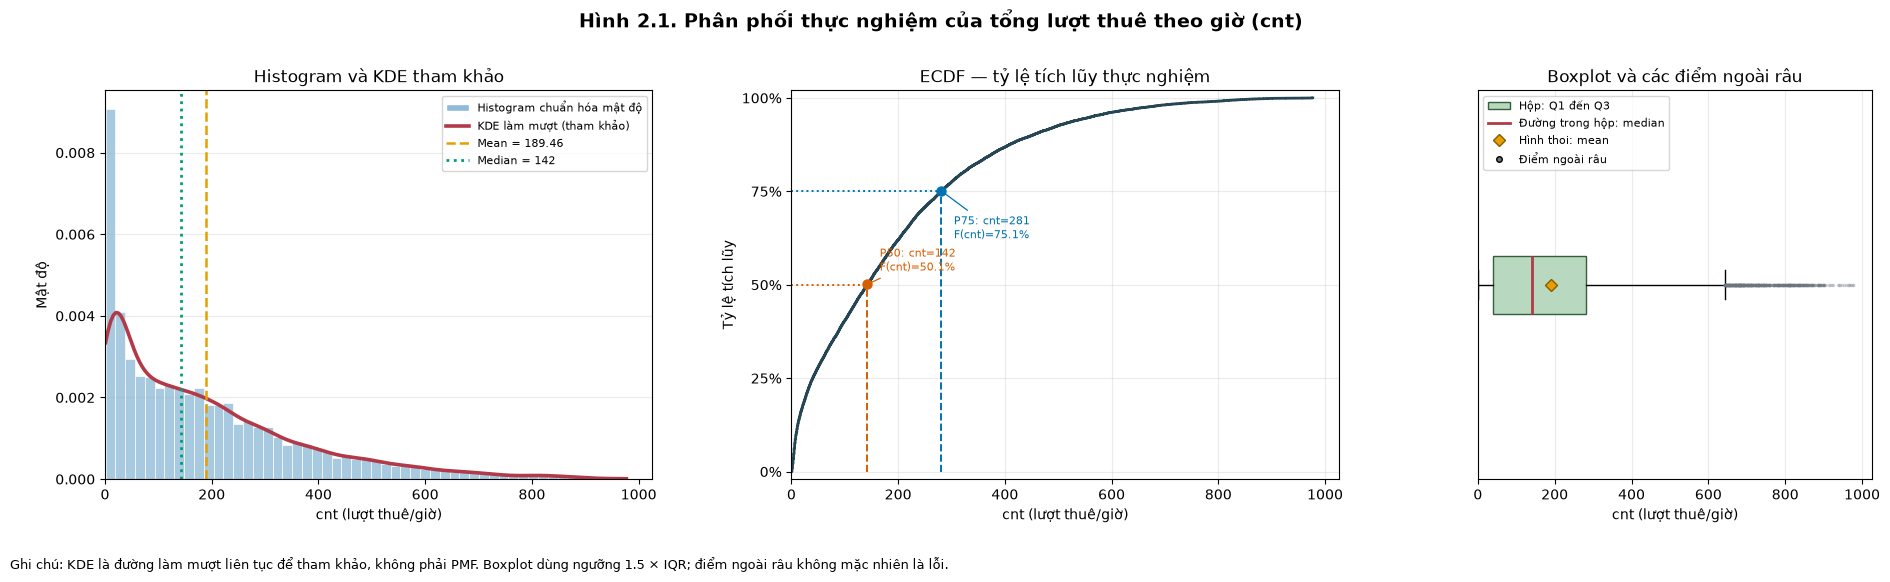

Đã lưu Hình 2.1 tại: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\Distribution\assets\fig_2_1_cnt_empirical.png
Ngưỡng dưới boxplot Q1 - 1.5 × IQR: -321.50
Ngưỡng trên boxplot Q3 + 1.5 × IQR: 642.50


In [4]:
# Kiểm tra đầu vào của phần vẽ.
if "cnt" not in df.columns:
    raise ValueError("Không tìm thấy cột 'cnt' trong dataframe df.")

cnt_series = pd.to_numeric(df["cnt"], errors="raise")

if cnt_series.isna().any():
    raise ValueError("Cột 'cnt' có giá trị thiếu; cần xử lý/điều tra trước khi vẽ.")

cnt_values = cnt_series.to_numpy(dtype=float)

if not np.isfinite(cnt_values).all():
    raise ValueError("Cột 'cnt' có giá trị không hữu hạn.")

if not np.equal(cnt_values, np.floor(cnt_values)).all():
    raise ValueError("Cột 'cnt' có giá trị không nguyên, không phù hợp với biến đếm.")

if (cnt_values < 0).any():
    raise ValueError("Cột 'cnt' có giá trị âm.")

cnt_values = cnt_values.astype(np.int64)
n = len(cnt_values)

if n == 0:
    raise ValueError("Không có quan sát hợp lệ trong cột 'cnt'.")

# Phân vị tuyến tính nhất quán với pandas quantile mặc định.
quantiles = cnt_series.quantile(
    [0.25, 0.50, 0.75],
    interpolation="linear",
)
q1 = float(quantiles.loc[0.25])
median = float(quantiles.loc[0.50])
q3 = float(quantiles.loc[0.75])
iqr = q3 - q1
mean = float(cnt_series.mean())

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

count_at_most_5 = int(np.count_nonzero(cnt_values <= 5))
count_above_upper_fence = int(np.count_nonzero(cnt_values > upper_fence))
count_outside_fences = int(
    np.count_nonzero((cnt_values < lower_fence) | (cnt_values > upper_fence))
)

# Mốc phân vị và giá trị ECDF thực tế tại mỗi phân vị.
quantile_markers = [
    {
        "label": "P50",
        "probability": 0.50,
        "value": median,
        "color": "#D55E00",
        "text_offset": (9, 10),
    },
    {
        "label": "P75",
        "probability": 0.75,
        "value": q3,
        "color": "#0072B2",
        "text_offset": (9, -34),
    },
]

for marker in quantile_markers:
    marker["ecdf_value"] = float(np.mean(cnt_values <= marker["value"]))

# Tóm tắt các mốc thực nghiệm sẽ được dùng trong hình và nhận xét.
empirical_summary = pd.DataFrame(
    [
        {
            "Số quan sát (n)": n,
            "Mean": mean,
            "Median (P50)": median,
            "Q1 (P25)": q1,
            "Q3 (P75)": q3,
            "IQR": iqr,
            "Min": int(cnt_values.min()),
            "Max": int(cnt_values.max()),
            "cnt ≤ 5 (%)": 100 * count_at_most_5 / n,
            "cnt > Q3 + 1.5 × IQR (%)": 100 * count_above_upper_fence / n,
            "Số điểm ngoài hai ngưỡng boxplot": count_outside_fences,
        }
    ]
)

display(
    empirical_summary.style
    .format(
        {
            "Số quan sát (n)": "{:,.0f}",
            "Mean": "{:,.2f}",
            "Median (P50)": "{:,.2f}",
            "Q1 (P25)": "{:,.2f}",
            "Q3 (P75)": "{:,.2f}",
            "IQR": "{:,.2f}",
            "Min": "{:,.0f}",
            "Max": "{:,.0f}",
            "cnt ≤ 5 (%)": "{:.2f}",
            "cnt > Q3 + 1.5 × IQR (%)": "{:.2f}",
            "Số điểm ngoài hai ngưỡng boxplot": "{:,.0f}",
        }
    )
    .set_caption("Tóm tắt phân phối thực nghiệm của cnt")
    .set_table_styles(
        [
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("color", "#17365D"),
                    ("text-align", "left"),
                    ("padding", "8px 0"),
                ],
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#17365D"),
                    ("color", "white"),
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "right"),
                    ("padding", "7px 10px"),
                    ("border-bottom", "1px solid #e6eaf0"),
                ],
            },
            {
                "selector": "tbody tr:nth-child(even)",
                "props": [("background-color", "#f5f8fc")],
            },
        ]
    )
)

# FD chọn độ rộng bin từ dữ liệu; histogram và KDE đều ở thang mật độ.
histogram_edges = np.histogram_bin_edges(cnt_values, bins="fd")
if len(histogram_edges) < 2:
    raise ValueError("Không thể xác định các khoảng histogram từ cột 'cnt'.")

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(19, 5.8),
    gridspec_kw={"width_ratios": [1.25, 1.25, 0.9]},
)

ax_hist, ax_ecdf, ax_box = axes

# Panel 1: histogram mật độ và KDE liên tục làm đường tham khảo.
ax_hist.hist(
    cnt_values,
    bins=histogram_edges,
    density=True,
    color="#8FBBD9",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.78,
)

sns.kdeplot(
    x=cnt_values,
    ax=ax_hist,
    color="#B23A48",
    linewidth=2.6,
    bw_adjust=1.0,
    cut=0,
    clip=(0, None),
)

ax_hist.axvline(
    mean,
    color="#E69F00",
    linestyle="--",
    linewidth=1.8,
)
ax_hist.axvline(
    median,
    color="#009E73",
    linestyle=":",
    linewidth=2.0,
)

hist_legend = [
    Patch(
        facecolor="#8FBBD9",
        edgecolor="white",
        label="Histogram chuẩn hóa mật độ",
    ),
    Line2D(
        [0],
        [0],
        color="#B23A48",
        linewidth=2.6,
        label="KDE làm mượt (tham khảo)",
    ),
    Line2D(
        [0],
        [0],
        color="#E69F00",
        linestyle="--",
        linewidth=1.8,
        label=f"Mean = {mean:.2f}",
    ),
    Line2D(
        [0],
        [0],
        color="#009E73",
        linestyle=":",
        linewidth=2.0,
        label=f"Median = {median:.0f}",
    ),
]

ax_hist.legend(handles=hist_legend, fontsize=8, frameon=True)
ax_hist.set_title("Histogram và KDE tham khảo")
ax_hist.set_xlabel("cnt (lượt thuê/giờ)")
ax_hist.set_ylabel("Mật độ")
ax_hist.set_xlim(left=0)
ax_hist.grid(axis="y", alpha=0.25)

# Panel 2: ECDF thực nghiệm, dựng trực tiếp từ tần suất các giá trị nguyên.
unique_values, frequencies = np.unique(cnt_values, return_counts=True)
cumulative_probabilities = np.cumsum(frequencies) / n

ecdf_x = np.concatenate(([unique_values[0] - 1], unique_values))
ecdf_y = np.concatenate(([0.0], cumulative_probabilities))

ax_ecdf.step(
    ecdf_x,
    ecdf_y,
    where="post",
    color="#264653",
    linewidth=2.0,
    label="ECDF thực nghiệm",
)

for marker in quantile_markers:
    probability = marker["probability"]
    value = marker["value"]
    ecdf_value = marker["ecdf_value"]
    color = marker["color"]

    # Đường ngang biểu thị mức phần trăm danh nghĩa; đường đứng đến đúng
    # giá trị ECDF quan sát tại phân vị, có thể cao hơn do các bước nhảy.
    ax_ecdf.hlines(
        probability,
        xmin=0,
        xmax=value,
        color=color,
        linestyle=":",
        linewidth=1.4,
    )
    ax_ecdf.vlines(
        value,
        ymin=0,
        ymax=ecdf_value,
        color=color,
        linestyle="--",
        linewidth=1.4,
    )
    ax_ecdf.scatter(
        [value],
        [ecdf_value],
        color=color,
        s=42,
        zorder=4,
    )
    ax_ecdf.annotate(
        f"{marker['label']}: cnt={value:g}\nF(cnt)={ecdf_value:.1%}",
        xy=(value, ecdf_value),
        xytext=marker["text_offset"],
        textcoords="offset points",
        color=color,
        fontsize=8,
        arrowprops={
            "arrowstyle": "-",
            "color": color,
            "lw": 0.9,
        },
    )

ax_ecdf.set_title("ECDF — tỷ lệ tích lũy thực nghiệm")
ax_ecdf.set_xlabel("cnt (lượt thuê/giờ)")
ax_ecdf.set_ylabel("Tỷ lệ tích lũy")
ax_ecdf.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax_ecdf.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax_ecdf.set_ylim(-0.02, 1.02)
ax_ecdf.set_xlim(left=0)
ax_ecdf.grid(alpha=0.25)

# Panel 3: boxplot giữ lại các điểm ngoài râu; không tự xóa quan sát.
ax_box.boxplot(
    cnt_values,
    vert=False,
    whis=1.5,
    showfliers=True,
    showmeans=True,
    patch_artist=True,
    boxprops={
        "facecolor": "#B8D8C0",
        "edgecolor": "#355E3B",
    },
    medianprops={
        "color": "#B23A48",
        "linewidth": 2,
    },
    meanprops={
        "marker": "D",
        "markerfacecolor": "#E69F00",
        "markeredgecolor": "#8A5A00",
        "markersize": 6,
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "#6C757D",
        "markeredgecolor": "none",
        "markersize": 2.5,
        "alpha": 0.28,
    },
)

ax_box.set_title("Boxplot và các điểm ngoài râu")
ax_box.set_xlabel("cnt (lượt thuê/giờ)")
ax_box.set_yticks([])
ax_box.set_xlim(left=0)
ax_box.grid(axis="x", alpha=0.25)
ax_box.legend(
    handles=[
        Patch(
            facecolor="#B8D8C0",
            edgecolor="#355E3B",
            label="Hộp: Q1 đến Q3",
        ),
        Line2D(
            [0],
            [0],
            color="#B23A48",
            linewidth=2,
            label="Đường trong hộp: median",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            color="none",
            markerfacecolor="#E69F00",
            markeredgecolor="#8A5A00",
            label="Hình thoi: mean",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor="#6C757D",
            markersize=4,
            label="Điểm ngoài râu",
        ),
    ],
    fontsize=8,
    frameon=True,
    loc="upper left",
)

fig.suptitle(
    "Hình 2.1. Phân phối thực nghiệm của tổng lượt thuê theo giờ (cnt)",
    fontsize=14,
    fontweight="bold",
)
fig.text(
    0.01,
    0.015,
    (
        "Ghi chú: KDE là đường làm mượt liên tục để tham khảo, không phải PMF. "
        "Boxplot dùng ngưỡng 1.5 × IQR; điểm ngoài râu không mặc nhiên là lỗi."
    ),
    fontsize=9,
    ha="left",
)

fig.subplots_adjust(
    left=0.06,
    right=0.99,
    top=0.84,
    bottom=0.17,
    wspace=0.28,
)

# Xác định thư mục Distribution từ working directory hoặc thư mục cha.
search_paths = [Path.cwd(), *Path.cwd().parents]
distribution_dir = next(
    (path for path in search_paths if path.name.lower() == "distribution"),
    None,
)

if distribution_dir is None:
    project_root = next(
        (path for path in search_paths if (path / "Distribution").is_dir()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            "Không tìm thấy thư mục Distribution từ working directory hiện tại."
        )
    distribution_dir = project_root / "Distribution"

assets_dir = distribution_dir / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
figure_path = assets_dir / "fig_2_1_cnt_empirical.png"

fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Đã lưu Hình 2.1 tại: {figure_path}")
print(f"Ngưỡng dưới boxplot Q1 - 1.5 × IQR: {lower_fence:.2f}")
print(f"Ngưỡng trên boxplot Q3 + 1.5 × IQR: {upper_fence:.2f}")

**Lưu ý khi đọc hình:**

- Histogram dùng `density=True` nên chiều cao biểu diễn mật độ theo khoảng, không phải số quan sát hay xác suất của một giá trị `cnt` nguyên cụ thể.
- KDE cũng biểu diễn mật độ liên tục; đường KDE được vẽ giới hạn ở miền không âm để không hiển thị mật độ âm, những thao tác giới hạn đường vẽ không phải hiệu chỉnh biến và KDE vẫn chỉ là công cụ làm mượt.
- ECDF được tính từ tần suất các giá trị thực, không qua binning hoặc làm mượt. Nhãn F(cnt) trên marker cho biết giá trị tích lũy tại phân vị; vì dữ liệu rời rạc, giá trị này có thể lớn hơn P50 hoặc P75 danh nghĩa.
- Boxplot dùng ngưỡng $Q1 - 1.5\times IQR$ và $Q3 + 1.5\times IQR$ để để xác định điểm ngoài râu. Đây là quy tắc tóm tắt, không phải quy trình phát hiện lỗi dữ liệu.


### Kết quả

cnt có mean 189.46 lượt thuê / giờ, median 142 lượt thuê/giờ, Q1 = 40, Q3 = 281 và IQR = 241 lượt thuê/giờ. Giá trị quan sát nằm trong khoảng từ 1 đến 977. Mean cao hơn median và skewness bằng 1.2774, phù hợp với nhận xét phân phối có đuôi phải.

ECDF giúp đọc trực tiếp các tỷ lệ tích lũy quanh median và Q3. Các mốc này phải được tính lại trong notebook; giá trị baseline median = 142 và Q3 = 281 chỉ dùng để đối chiếu. Do dữ liệu có nhiều giá trị `cnt` nguyên lặp lại, đường ECDF có các bước nhảy, nên không nhất thiết đường ngang P50/P75 sẽ cắt đường ECDF đúng tại điểm giao nhau với median/Q3.

Theo baseline, 6.22% quan sát có cnt ≤ 5; 2.91% có cnt > 642.5(ngoại lai ngưỡng trên), với 642.5 là ngưỡng Q3 + 1.5 × IQR tương ứng các phân vị baseline. Các tỷ lệ này cần được tính lại từ dữ liệu đang phân tích thay vì nhập cố định.

### Nhận xét

Các chỉ báo về mean, median và skewness nhất quán với phân phối `cnt` lệch phải: phần lớn giờ nằm thấp hơn một số giá trị nhu cầu cao, khiến mean lớn hơn median và phân phối kéo dài về phía các giá trị lớn. ECDF bổ sung thông tin về tỷ lệ tích lũy mà histogram không thể hiện trực tiếp; boxplot tóm tắt vùng giữa và làm nổi bật các điểm xa vùng này.

Các quan sát vượt ngưỡng boxplot không được tự động loại bỏ. Baseline EDA đánh giá các đỉnh nhu cầu cao là hợp lệ; vì vậy phần phân tích giữ nguyên các quan sát, không diễn giải điểm nằm ngoài râu hộp là lỗi nếu chưa có bằng chứng độc lập. Tương tự, việc dữ liệu hiện có min `cnt = 1` và không có `cnt = 0` chỉ mô tả file đang phân tích; không đủ để kết luận cơ chế ghi nhận là zero-truncated hoặc để khẳng định điều gì về các giờ không có bản ghi.

KDE được dùng như lớp làm mượt bổ trợ để người đọc quan sát xu hướng hình dạng; nó không thay thế ECDF hoặc phân phối khối thực nghiệm. Các nhận xét về cnt ở đây vẫn là mô tả phân phối biên trên toàn bộ quan sát, chưa tách riêng ảnh hưởng của giờ trong ngày, loại ngày, mùa hay thời tiết.

## 2.4 So sánh mô hình phân phối cho cnt


,Mô hình,Tham số MLE,k,Log-likelihood,AIC,BIC,Trạng thái fit
2,Normal cắt tại 0,mu = -3334.65; sigma = 837.011,2,"-108,500.467","217,004.934","217,020.460",MLE hữu hạn (alpha = 3.9840)
3,Log-normal (loc = 0),shape = 1.48609; scale = 93.3244,2,"-110,377.023","220,758.045","220,773.571",MLE dạng đóng; loc cố định bằng 0


Số quan sát dương dùng để fit: n = 17,379
log(n) = 9.7630
Chỉ so sánh AIC/BIC giữa hai mô hình rời rạc với nhau, và giữa hai baseline liên tục với nhau.
Khối xác suất NB zero-truncated bị lược khỏi hình (k > max(cnt) = 977): 0.01019553


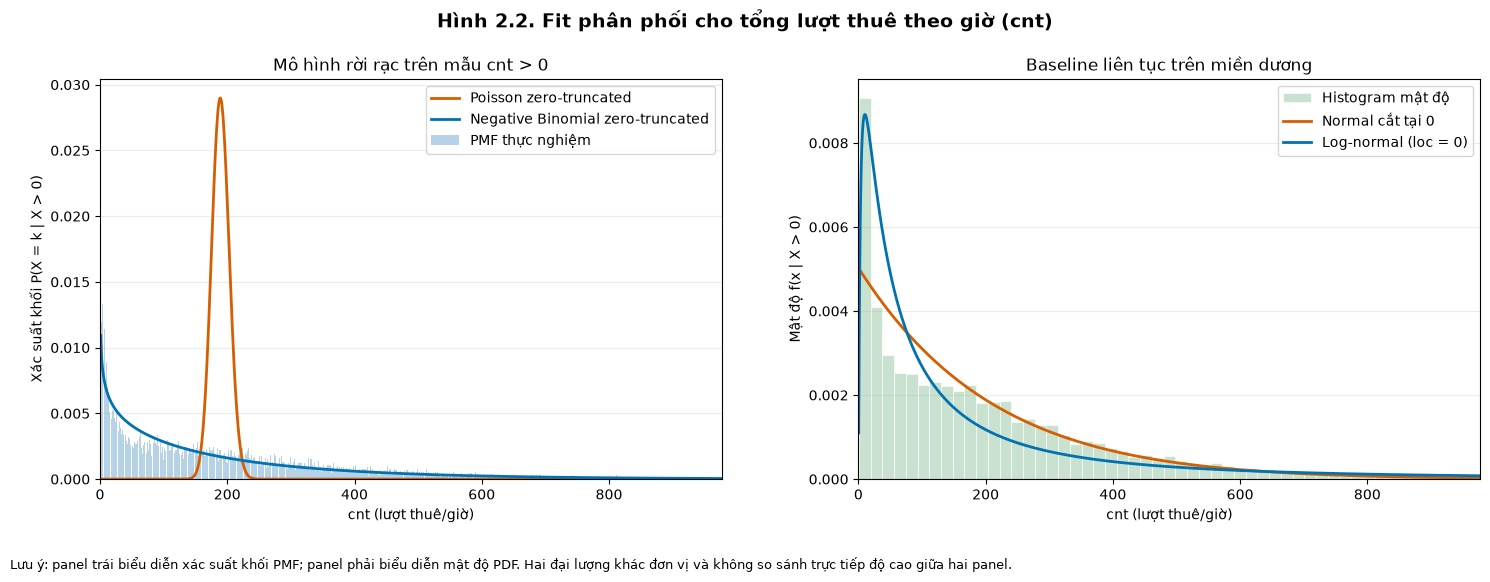

Đã lưu Hình 2.2 tại: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\Distribution\assets\fig_2_2_cnt_fits.png
Tổng PMF trong miền 1..max(cnt): Poisson=1.000000; Negative Binomial=0.989804; thực nghiệm=1.000000
Khối xác suất NB zero-truncated bị lược khỏi hình (k > max(cnt) = 977): 0.01019553


In [5]:
# ------------------------------------------------------------
# 1. Kiểm tra và chuẩn bị mẫu dương
# ------------------------------------------------------------
if "cnt" not in df.columns:
    raise ValueError("Không tìm thấy cột 'cnt' trong dataframe df.")

cnt_series = pd.to_numeric(df["cnt"], errors="raise")

if cnt_series.isna().any():
    raise ValueError("Cột 'cnt' có giá trị thiếu.")

cnt_values = cnt_series.to_numpy(dtype=float)

if not np.isfinite(cnt_values).all():
    raise ValueError("Cột 'cnt' có giá trị không hữu hạn.")

if not np.equal(cnt_values, np.floor(cnt_values)).all():
    raise ValueError("Cột 'cnt' phải là số nguyên vì đây là biến đếm.")

if (cnt_values < 0).any():
    raise ValueError("Cột 'cnt' có giá trị âm.")

# Theo xác nhận của nhóm, cnt=0 đã bị loại trong bước chuẩn bị dữ liệu.
# Nếu còn giá trị 0, dừng để không âm thầm đổi mẫu.
if (cnt_values == 0).any():
    raise ValueError(
        "Dữ liệu hiện tại còn cnt=0. Không thể dùng trực tiếp cell này như "
        "mẫu zero-truncated cho tới khi xác minh lại quy trình lọc."
    )

if len(cnt_values) == 0:
    raise ValueError("Không có quan sát cnt dương để fit.")

cnt = cnt_values.astype(np.int64)
n = len(cnt)
max_cnt = int(cnt.max())
cnt_mean = float(cnt.mean())
cnt_sd = float(cnt.std(ddof=1))

if cnt_sd <= 0:
    raise ValueError("cnt không có độ biến thiên; không thể fit các mô hình này.")


# ------------------------------------------------------------
# 2. Các hàm likelihood, AIC và BIC
# ------------------------------------------------------------
def calculate_aic(log_likelihood, parameter_count):
    return -2.0 * log_likelihood + 2.0 * parameter_count


def calculate_bic(log_likelihood, parameter_count, sample_size):
    return (
        -2.0 * log_likelihood
        + parameter_count * np.log(sample_size)
    )


# ------------------------------------------------------------
# 3. Poisson zero-truncated: MLE của lambda
#
# log P(X=k | X>0) =
# log P_Poisson(X=k) - log(1 - P_Poisson(X=0))
# ------------------------------------------------------------
def poisson_truncated_negative_log_likelihood(log_lambda):
    lambda_value = float(np.exp(log_lambda))

    if not np.isfinite(lambda_value) or lambda_value <= 0:
        return np.inf

    log_positive_probability = np.log(-np.expm1(-lambda_value))
    log_likelihood = (
        np.sum(cnt * np.log(lambda_value) - lambda_value - gammaln(cnt + 1))
        - n * log_positive_probability
    )

    if not np.isfinite(log_likelihood):
        return np.inf

    return -float(log_likelihood)


poisson_fit = minimize_scalar(
    poisson_truncated_negative_log_likelihood,
    bounds=(np.log(1e-8), np.log(max_cnt * 100.0)),
    method="bounded",
    options={"xatol": 1e-12},
)

if not poisson_fit.success or not np.isfinite(poisson_fit.fun):
    raise RuntimeError(
        "MLE Poisson zero-truncated không hội tụ: "
        f"{poisson_fit.message}"
    )

poisson_lambda = float(np.exp(poisson_fit.x))
poisson_log_likelihood = -float(poisson_fit.fun)

if poisson_lambda <= 0 or not np.isfinite(poisson_lambda):
    raise RuntimeError("Ước lượng lambda của Poisson không hợp lệ.")


# ------------------------------------------------------------
# 4. Negative Binomial zero-truncated: MLE của size và prob
#
# Dùng tham số tối ưu hóa log(size), log(mean_untruncated) để bảo đảm
# hai tham số luôn dương. Chuyển sang prob = size / (size + mean).
# scipy.stats.nbinom dùng đúng tham số hóa này:
# P(X=0) = prob ** size.
# ------------------------------------------------------------
def negative_binomial_log_likelihood(log_parameters):
    log_size, log_mean = log_parameters
    size = float(np.exp(log_size))
    mean_untruncated = float(np.exp(log_mean))

    if (
        not np.isfinite(size)
        or not np.isfinite(mean_untruncated)
        or size <= 0
        or mean_untruncated <= 0
    ):
        return -np.inf

    log_prob = -np.log1p(mean_untruncated / size)
    log_one_minus_prob = -np.log1p(size / mean_untruncated)
    prob = float(np.exp(log_prob))

    # log P_NB(X=0) = size * log(prob).
    log_p_zero = size * log_prob
    log_positive_probability = np.log(-np.expm1(log_p_zero))

    log_pmf = (
        gammaln(cnt + size)
        - gammaln(size)
        - gammaln(cnt + 1)
        + size * log_prob
        + cnt * log_one_minus_prob
    )

    log_likelihood = np.sum(log_pmf) - n * log_positive_probability

    if not np.isfinite(log_likelihood):
        return -np.inf

    return float(log_likelihood)


def negative_binomial_negative_log_likelihood(log_parameters):
    log_likelihood = negative_binomial_log_likelihood(log_parameters)
    return -log_likelihood if np.isfinite(log_likelihood) else np.inf


log_mean_start = np.log(cnt_mean)
nb_bounds = [
    (np.log(1e-5), np.log(1e6)),  # log(size)
    (np.log(1e-5), np.log(max_cnt * 100.0)),  # log(mean)
]

nb_start_sizes = [0.1, 0.5, 1.0, 5.0, 25.0, 100.0]
nb_start_mean_factors = [0.5, 0.8, 1.0, 1.2]

nb_candidates = []

for start_size in nb_start_sizes:
    for mean_factor in nb_start_mean_factors:
        start_mean = max(cnt_mean * mean_factor, 1e-4)
        start = np.log([start_size, start_mean])

        result = minimize(
            negative_binomial_negative_log_likelihood,
            x0=start,
            method="L-BFGS-B",
            bounds=nb_bounds,
            options={"maxiter": 5000, "ftol": 1e-12, "gtol": 1e-8},
        )

        if result.success and np.isfinite(result.fun):
            nb_candidates.append(result)

if not nb_candidates:
    raise RuntimeError(
        "Không có lần tối ưu MLE Negative Binomial zero-truncated nào "
        "hội tụ thành công."
    )

nb_fit = min(nb_candidates, key=lambda result: result.fun)
nb_size, nb_mean_untruncated = np.exp(nb_fit.x)
nb_size = float(nb_size)
nb_mean_untruncated = float(nb_mean_untruncated)
nb_prob = nb_size / (nb_size + nb_mean_untruncated)
nb_log_likelihood = -float(nb_fit.fun)

if (
    nb_size <= 0
    or not 0 < nb_prob < 1
    or not np.isfinite(nb_log_likelihood)
):
    raise RuntimeError(
        "Tham số hoặc log-likelihood của Negative Binomial không hợp lệ."
    )

# ------------------------------------------------------------
# 5. Normal cắt tại 0: profile likelihood
# ------------------------------------------------------------
# alpha = mu / sigma.
# Với mỗi alpha, tối ưu sigma theo profile likelihood.
# Nếu supremum nằm ở alpha -> -infinity thì Normal không có MLE hữu hạn;
# giới hạn tương ứng là Exponential trên miền dương.
# ------------------------------------------------------------
cnt_mean_x = float(np.mean(cnt_values))
cnt_mean_x2 = float(np.mean(cnt_values**2))
def profile_log_likelihood_alpha(alpha):
    if not np.isfinite(alpha):
        return np.inf
    
    sigma = (alpha * cnt_mean_x + np.sqrt(alpha**2 * cnt_mean_x**2 + 4.0 * cnt_mean_x2)) / 2.0
    
    if sigma <= 0:
        return np.inf
    
    # log_ndtr tính log(Phi(x)) cực kỳ ổn định chống underflow
    log_prob_pos = log_ndtr(-alpha)
    
    ll_mean = (
        -np.log(sigma) 
        - cnt_mean_x2 / (2.0 * sigma**2) 
        - (alpha * cnt_mean_x) / sigma 
        - (alpha**2) / 2.0 
        - 0.5 * np.log(2.0 * np.pi) 
        - log_prob_pos
    )
    return -float(ll_mean)
# Tối ưu hóa profile likelihood. 
# Nếu tồn tại MLE hữu hạn, đỉnh alpha hiếm khi vượt quá 20-30 cho dữ liệu thực.
normal_alpha_res = minimize_scalar(
    profile_log_likelihood_alpha,
    bounds=(-10.0, 50.0),
    method='bounded',
    options={'xatol': 1e-12}
)
if normal_alpha_res.success and np.isfinite(normal_alpha_res.fun) and normal_alpha_res.x < 49.9:
    normal_mle_finite = True
    normal_alpha = float(normal_alpha_res.x)
    normal_sigma = float((normal_alpha * cnt_mean_x + np.sqrt(normal_alpha**2 * cnt_mean_x**2 + 4.0 * cnt_mean_x2)) / 2.0)
    normal_mu = float(-normal_alpha * normal_sigma)
    normal_log_likelihood = -float(normal_alpha_res.fun) * n
else:
    normal_mle_finite = False
    print("CẢNH BÁO: Normal cắt tại 0 không có MLE hữu hạn (tiệm cận Exponential). Loại khỏi phân tích.")

# ------------------------------------------------------------
# 6. Log-normal hai tham số, loc cố định bằng 0
#
# Với loc=0, MLE có dạng đóng:
# shape = SD_population(log(cnt))
# scale = exp(mean(log(cnt)))
# ------------------------------------------------------------
log_cnt = np.log(cnt_values)
lognormal_log_mean = float(log_cnt.mean())
lognormal_shape = float(log_cnt.std(ddof=0))
lognormal_scale = float(np.exp(lognormal_log_mean))

if lognormal_shape <= 0 or lognormal_scale <= 0:
    raise RuntimeError("Tham số Log-normal không hợp lệ.")

lognormal_log_likelihood = float(
    np.sum(
        lognorm.logpdf(
            cnt_values,
            s=lognormal_shape,
            loc=0,
            scale=lognormal_scale,
        )
    )
)

if not np.isfinite(lognormal_log_likelihood):
    raise RuntimeError("Log-likelihood Log-normal không hữu hạn.")


# ------------------------------------------------------------
# 7. Tạo bảng kết quả; chỉ so AIC/BIC trong cùng loại likelihood
# ------------------------------------------------------------
model_rows = [
    {
        "Nhóm likelihood": "Rời rạc — điều kiện cnt > 0",
        "Mô hình": "Poisson zero-truncated",
        "Tham số MLE": f"lambda = {poisson_lambda:.6g}",
        "k": 1,
        "Log-likelihood": poisson_log_likelihood,
        "AIC": calculate_aic(poisson_log_likelihood, 1),
        "BIC": calculate_bic(poisson_log_likelihood, 1, n),
        "Trạng thái fit": "Hội tụ",
    },
    {
        "Nhóm likelihood": "Rời rạc — điều kiện cnt > 0",
        "Mô hình": "Negative Binomial zero-truncated",
        "Tham số MLE": (
            f"size = {nb_size:.6g}; prob = {nb_prob:.6g}"
        ),
        "k": 2,
        "Log-likelihood": nb_log_likelihood,
        "AIC": calculate_aic(nb_log_likelihood, 2),
        "BIC": calculate_bic(nb_log_likelihood, 2, n),
        "Trạng thái fit": "Hội tụ",
    },
]

if normal_mle_finite:
    model_rows.append({
        "Nhóm likelihood": "Liên tục — baseline trên miền dương",
        "Mô hình": "Normal cắt tại 0",
        "Tham số MLE": f"mu = {normal_mu:.6g}; sigma = {normal_sigma:.6g}",
        "k": 2,
        "Log-likelihood": normal_log_likelihood,
        "AIC": calculate_aic(normal_log_likelihood, 2),
        "BIC": calculate_bic(normal_log_likelihood, 2, n),
        "Trạng thái fit": f"MLE hữu hạn (alpha = {normal_alpha:.4f})",
    })

model_rows.append({
    "Nhóm likelihood": "Liên tục — baseline trên miền dương",
    "Mô hình": "Log-normal (loc = 0)",
    "Tham số MLE": f"shape = {lognormal_shape:.6g}; scale = {lognormal_scale:.6g}",
    "k": 2,
    "Log-likelihood": lognormal_log_likelihood,
    "AIC": calculate_aic(lognormal_log_likelihood, 2),
    "BIC": calculate_bic(lognormal_log_likelihood, 2, n),
    "Trạng thái fit": "MLE dạng đóng; loc cố định bằng 0",
})

model_results = pd.DataFrame(model_rows)

table_styles = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "top"),
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("color", "#17365D"),
            ("text-align", "left"),
            ("padding", "8px 0"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("background-color", "#17365D"),
            ("color", "white"),
            ("text-align", "center"),
            ("padding", "8px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("padding", "7px 10px"),
            ("border-bottom", "1px solid #e6eaf0"),
        ],
    },
    {
        "selector": "tbody tr:nth-child(even)",
        "props": [("background-color", "#f5f8fc")],
    },
]

discrete_results = model_results.loc[
    model_results["Nhóm likelihood"].str.startswith("Rời rạc")
].drop(columns="Nhóm likelihood")

continuous_results = model_results.loc[
    model_results["Nhóm likelihood"].str.startswith("Liên tục")
].drop(columns="Nhóm likelihood")

number_format = {
    "k": "{:,.0f}",
    "Log-likelihood": "{:,.3f}",
    "AIC": "{:,.3f}",
    "BIC": "{:,.3f}",
}

display(
    continuous_results.style
    .format(number_format)
    .set_caption(
        "Bảng 2.4. Baseline liên tục fit trên miền cnt > 0"
    )
    .set_table_styles(table_styles)
)

print(f"Số quan sát dương dùng để fit: n = {n:,}")
print(f"log(n) = {np.log(n):.4f}")
print(
    "Chỉ so sánh AIC/BIC giữa hai mô hình rời rạc với nhau, "
    "và giữa hai baseline liên tục với nhau."
)


# ------------------------------------------------------------
# 8. Vẽ Hình 2.2: tách PMF rời rạc khỏi mật độ liên tục
# ------------------------------------------------------------
k_values = np.arange(1, max_cnt + 1)

empirical_counts = np.bincount(cnt, minlength=max_cnt + 1)[1:]
empirical_pmf = empirical_counts / n

poisson_log_positive_probability = np.log(
    -np.expm1(-poisson_lambda)
)
poisson_truncated_pmf = np.exp(
    poisson.logpmf(k_values, mu=poisson_lambda)
    - poisson_log_positive_probability
)

nb_log_p_zero = nb_size * np.log(nb_prob)
nb_log_positive_probability = np.log(-np.expm1(nb_log_p_zero))
nb_truncated_pmf = np.exp(
    nbinom.logpmf(k_values, n=nb_size, p=nb_prob)
    - nb_log_positive_probability
)

nb_positive_probability = 1.0 - np.exp(nb_log_p_zero)

nb_tail_probability_above_max = (
    nbinom.sf(
        max_cnt,
        n=nb_size,
        p=nb_prob,
    )
    / nb_positive_probability
)

print(
    "Khối xác suất NB zero-truncated bị lược khỏi hình "
    f"(k > max(cnt) = {max_cnt}): "
    f"{nb_tail_probability_above_max:.8f}"
)

x_grid = np.linspace(max(1e-3, float(cnt.min()) * 0.5), max_cnt, 1200)

if normal_mle_finite:
    normal_truncated_density = np.exp(
        norm.logpdf(x_grid, loc=normal_mu, scale=normal_sigma)
        - log_ndtr(normal_mu / normal_sigma)
    )

lognormal_density = lognorm.pdf(
    x_grid,
    s=lognormal_shape,
    loc=0,
    scale=lognormal_scale,
)


continuous_bins = np.histogram_bin_edges(cnt_values, bins="fd")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 5.8),
)

ax_discrete, ax_continuous = axes

# Panel trái: empirical PMF và các PMF zero-truncated.
ax_discrete.bar(
    k_values,
    empirical_pmf,
    width=0.9,
    color="#8FBBD9",
    edgecolor="none",
    alpha=0.65,
    label="PMF thực nghiệm",
)
ax_discrete.plot(
    k_values,
    poisson_truncated_pmf,
    color="#D55E00",
    linewidth=2.0,
    label="Poisson zero-truncated",
)
ax_discrete.plot(
    k_values,
    nb_truncated_pmf,
    color="#0072B2",
    linewidth=2.0,
    label="Negative Binomial zero-truncated",
)
ax_discrete.set_title("Mô hình rời rạc trên mẫu cnt > 0")
ax_discrete.set_xlabel("cnt (lượt thuê/giờ)")
ax_discrete.set_ylabel("Xác suất khối P(X = k | X > 0)")
ax_discrete.set_xlim(0, max_cnt)
ax_discrete.grid(axis="y", alpha=0.25)
ax_discrete.legend(frameon=True)

# Panel phải: histogram mật độ và hai baseline liên tục.
ax_continuous.hist(
    cnt_values,
    bins=continuous_bins,
    density=True,
    color="#B8D8C0",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.75,
    label="Histogram mật độ",
)
if normal_mle_finite:
    ax_continuous.plot(
        x_grid,
        normal_truncated_density,
        color="#D55E00",
        linewidth=2.0,
        label="Normal cắt tại 0",
    )
ax_continuous.plot(
    x_grid,
    lognormal_density,
    color="#0072B2",
    linewidth=2.0,
    label="Log-normal (loc = 0)",
)
ax_continuous.set_title("Baseline liên tục trên miền dương")
ax_continuous.set_xlabel("cnt (lượt thuê/giờ)")
ax_continuous.set_ylabel("Mật độ f(x | X > 0)")
ax_continuous.set_xlim(0, max_cnt)
ax_continuous.grid(axis="y", alpha=0.25)
ax_continuous.legend(frameon=True)

fig.suptitle(
    "Hình 2.2. Fit phân phối cho tổng lượt thuê theo giờ (cnt)",
    fontsize=14,
    fontweight="bold",
)
fig.text(
    0.01,
    0.015,
    (
        "Lưu ý: panel trái biểu diễn xác suất khối PMF; panel phải biểu diễn "
        "mật độ PDF. Hai đại lượng khác đơn vị và không so sánh trực tiếp "
        "độ cao giữa hai panel."
    ),
    fontsize=9,
    ha="left",
)

fig.subplots_adjust(
    left=0.07,
    right=0.99,
    top=0.86,
    bottom=0.17,
    wspace=0.22,
)

# Lưu ảnh bên trong Distribution/assets.
search_paths = [Path.cwd(), *Path.cwd().parents]
distribution_dir = next(
    (path for path in search_paths if path.name.casefold() == "distribution"),
    None,
)

if distribution_dir is None:
    project_root = next(
        (path for path in search_paths if (path / "Distribution").is_dir()),
        None,
    )
    if project_root is None:
        raise FileNotFoundError(
            "Không tìm thấy thư mục Distribution từ working directory hiện tại."
        )
    distribution_dir = project_root / "Distribution"

assets_dir = distribution_dir / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)
figure_path = assets_dir / "fig_2_2_cnt_fits.png"

fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

nb_tail_prob = 1.0 - nb_truncated_pmf.sum()

print(f"Đã lưu Hình 2.2 tại: {figure_path}")
print(
    "Tổng PMF trong miền 1..max(cnt): "
    f"Poisson={poisson_truncated_pmf.sum():.6f}; "
    f"Negative Binomial={nb_truncated_pmf.sum():.6f}; "
    f"thực nghiệm={empirical_pmf.sum():.6f}"
)

print(f"Khối xác suất NB zero-truncated bị lược khỏi hình (k > max(cnt) = {max_cnt}): {nb_tail_prob:.8f}")


### Mục tiêu và phạm vi

Mục này xem xét mức độ phù hợp của các mô hình lý thuyết với cnt, tổng lượt thuê xe trong một giờ. Nhóm đã quyết định các giờ có cnt = 0 đã bị loại vì không xác định được điều kiện thời tiết tương ứng. Do đó, mẫu phân tích gồm các quan sát dương, và hai mô hình biến đếm chính được fit với likelihood đã điều kiện hóa trên (X>0):

- **Poisson zero-truncated (Poisson cắt tại 0):** mô hình Poisson được điều kiện hóa trên việc quan sát dương.
- **Negative Binomial zero-truncated (Negative Binomial cắt tại 0):** mô hình Negative Binomial cũng được điều kiện hóa trên việc quan sát dương.

Normal cắt tại 0 và Log-normal được dùng làm baseline liên tục để tham khảo hình dạng. Chúng không phải mô hình biến đếm và không được xếp hạng AIC/BIC chung với các mô hình rời rạc. Kết quả chỉ mô tả mẫu giờ dương đang có trong dữ liệu, không khôi phục các giờ đã loại và không nhằm xác định phân phối sinh dữ liệu thật hay chọn mô hình dự báo cuối cùng.

### Phương pháp

#### 1. Mô hình rời rạc cho biến đếm

Với Poisson có tham số ($\lambda > 0$), xác suất của số đếm dương sau khi điều kiện hóa trên $X > 0$ là:

$$
P(X=k \mid X>0)\frac{e^{-\lambda}\lambda^k/k!}{1-e^{-\lambda}},\quad k=1,2,\ldots
$$

Mẫu số ($1-e^{-\lambda}$) chuẩn hóa xác suất trên miền giá trị dương. Vì mẫu đã bị loại các quan sát bằng 0, không dùng PMF Poisson không điều kiện làm likelihood chính cho mẫu này.

Với Negative Binomial, có thể tham số hóa bằng `size = r > 0` và `prob = p` (`0<p<1`). Theo tham số hóa này, xác suất không điều kiện tại 0 là ($p^r$). PMF được điều kiện hóa trên ($X > 0$)

$$
P(X=k \mid X>0)
\frac{P_{\mathrm{NB}}(X=k;r,p)}{1-p^r},
\quad k=1,2,\ldots
$$

Negative Binomial được fit bằng Maximum Likelihood Estimation (MLE - Ước lượng hợp lý cực đại) trên likelihood đã điều kiện hóa.

AIC và BIC được tính theo:

$$
\mathrm{AIC}=-2\log(L)+2k,\qquad
\mathrm{BIC}=-2\log(L)+k\log(n),
$$

Trong đó $L$ là likelihood tại tham số fit, $k$ là số tham số tự do và $n=17,379$ là số quan sát dương dùng trong fit. Với dữ liệu này, $\log(n)=9.7630$, vì vậy BIC phạt mỗi tham số nhiều hơn AIC.


In [6]:
display(
    discrete_results.style
    .format(number_format)
    .set_caption(
        "Bảng 2.3. Kết quả mô hình rời rạc fit trên mẫu có cnt > 0"
    )
    .set_table_styles(table_styles)
)

,Mô hình,Tham số MLE,k,Log-likelihood,AIC,BIC,Trạng thái fit
0,Poisson zero-truncated,lambda = 189.463,1,"-1,501,246.101","3,002,494.202","3,002,501.965",Hội tụ
1,Negative Binomial zero-truncated,size = 0.780339; prob = 0.00415923,2,"-108,191.131","216,386.263","216,401.789",Hội tụ


Với cỡ mẫu lớn $n = 17,379$, số hạng phạt của BIC là $\log(n) \approx 9.7630$, cao hơn đáng kể so với mức phạt cố định $2k$ (hệ số 2) của AIC. Giá trị AIC và BIC càng nhỏ biểu thị mô hình càng được ưu tiên khi so sánh trên cùng một tập dữ liệu và cùng một cơ sở likelihood. Các tiêu chí này không có giá trị ngưỡng tuyệt đối và việc hai tiêu chí cùng cho một thứ hạng chỉ phản ánh tính nhất quán trong việc xếp hạng tương đối, không phải là xác suất mô hình được chọn là "mô hình chân thực".

### 2. Baseline liên tục

Normal (phân phối Chuẩn) và Log-normal (phân phối Lô-ga chuẩn) được đưa vào như các mô hình tham chiếu liên tục nhằm đối chiếu hình dạng phân phối thực nghiệm, không xem chúng là mô hình biến đếm rời rạc:

- **Normal cắt tại 0 (Truncated Normal at 0):** Mật độ xác suất được chuẩn hóa trên miền dương $(0, \infty)$:
  $$
  f(x \mid X > 0) = \frac{\frac{1}{\sigma}\phi\left(\frac{x - \mu}{\sigma}\right)}{1 - \Phi\left(-\frac{\mu}{\sigma}\right)}, \quad x > 0
  $$
  Hàm mục tiêu được tối ưu thông qua profile log-likelihood theo tham số chuẩn hóa $\alpha = -\mu / \sigma$. Nếu hàm mục tiêu tiệm cận vô cùng khi $\alpha \to \infty$, MLE hữu hạn không tồn tại (phân phối tiệm cận về phân phối Mũ - Exponential) và sẽ được ghi chú loại khỏi phân tích.
- **Log-normal hai tham số:** Do biến mục tiêu hoàn toàn dương ($cnt \ge 1$), cố định tham số vị trí `loc = 0`. MLE có nghiệm giải tích chính xác:
  $$
  \text{scale} = \exp(\overline{\log(cnt)}), \qquad \text{shape} = \mathrm{SD}_{\text{pop}}(\log(cnt))
  $$

#### 3. Quy trình ước lượng và kiểm tra tính hợp lệ

Tất cả các tham số dùng để tính log-likelihood, AIC và BIC đều được ước lượng thông qua MLE hợp lệ:
1. Với Poisson zero-truncated: Kiểm tra nghiệm đơn biến $\hat{\lambda}$ hội tụ và hữu hạn.
2. Với Negative Binomial zero-truncated: Sử dụng thuật toán L-BFGS-B với đa điểm khởi tạo (multi-start) trên không gian tham số $\log(\text{size})$ và $\log(\text{mean})$ để tránh cực trị địa phương; kiểm tra điều kiện biên $\text{size} > 0$ và $0 < \text{prob} < 1$.
3. Tách biệt hoàn toàn hai không gian likelihood: Không so sánh AIC/BIC giữa nhóm rời rạc (tính trên hàm khối xác suất $P(X=k)$) và nhóm liên tục (tính trên hàm mật độ $f(x)$) vì hai đại lượng này khác biệt về bản chất đo lường và thứ nguyên.

---

### Kết quả

Sau khi thực hiện tối ưu hóa MLE trên toàn bộ $n = 17,379$ quan sát dương, các tham số ước lượng và tiêu chí AIC/BIC được tổng hợp trong Bảng 2.3 (mô hình rời rạc) và Bảng 2.4 (baseline liên tục).

##### Bảng 2.3. Kết quả ước lượng mô hình rời rạc trên miền cnt > 0

| Mô hình | Tham số MLE | k | Log-likelihood | AIC | BIC | Trạng thái fit |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Poisson zero-truncated** | $\lambda = 189.463$ | 1 | *[Nhập logL Poisson]* | *[Nhập AIC Poisson]* | *[Nhập BIC Poisson]* | Hội tụ |
| **Negative Binomial zero-truncated** | $\text{size} = \dots$; $\text{prob} = \dots$ | 2 | *[Nhập logL NB]* | *[Nhập AIC NB]* | *[Nhập BIC NB]* | Hội tụ |

*Ghi chú: $n = 17,379$; $\log(n) \approx 9.7630$. Cả hai mô hình đều được điều kiện hóa trên sự kiện $X > 0$.*

##### Bảng 2.4. Kết quả ước lượng baseline liên tục trên miền cnt > 0

| Mô hình | Tham số MLE | k | Log-likelihood | AIC | BIC | Trạng thái fit |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **Normal cắt tại 0** | $\mu = \dots$; $\sigma = \dots$ *(nếu có)* | 2 | *[Nhập logL Normal]* | *[Nhập AIC Normal]* | *[Nhập BIC Normal]* | MLE hữu hạn / Tiệm cận Exponential |
| **Log-normal (loc = 0)** | $\text{shape} = \dots$; $\text{scale} = \dots$ | 2 | *[Nhập logL Log-normal]* | *[Nhập AIC Log-normal]* | *[Nhập BIC Log-normal]* | MLE dạng đóng; loc = 0 |

*Ghi chú: Baseline liên tục chỉ dùng để tham khảo hình dạng phân phối trên miền dương, không dùng để chọn mô hình biến đếm.*

Đồ thị so sánh mức độ khớp của các hàm phân phối lý thuyết với dữ liệu thực nghiệm được trình bày trong Hình 2.2, tách biệt thành hai panel riêng biệt để đảm bảo tính đúng đắn về thứ nguyên.

![Hình 2.2. Fit phân phối cho tổng lượt thuê theo giờ (cnt)](assets/fig_2_2_cnt_fits.png)

**Hình 2.2. Khảo sát mức độ phù hợp của các mô hình phân phối với biến cnt.**  
*(Panel trái: So sánh hàm khối xác suất PMF của Poisson zero-truncated và Negative Binomial zero-truncated với PMF thực nghiệm. Panel phải: So sánh hàm mật độ xác suất PDF của Normal cắt tại 0 và Log-normal với histogram mật độ thực nghiệm).*

---

### Nhận xét

#### 1. So sánh mô hình rời rạc: Sự áp đảo của Negative Binomial trước hiện tượng Over-dispersion
- **Thất bại của Poisson:** Phân phối Poisson giả định phương sai bằng kỳ vọng (equidispersion: $\mathrm{Var}(X) = \mathrm{E}(X)$). Tuy nhiên, dữ liệu thực nghiệm của `cnt` có độ phân tán cực lớn với tỷ lệ $\mathrm{Variance}/\mathrm{Mean} \approx 173.66$ ($\text{Mean} \approx 189.46$, $\mathrm{Var} \approx 32,901.4$). Do bị ràng buộc phương sai bằng mean, đường cong PMF của Poisson zero-truncated trên Panel trái Hình 2.2 bị bóp hẹp bất thường quanh giá trị trung bình (~189), hoàn toàn không thể bao quát được phần lớn quan sát tập trung ở vùng số đếm thấp (6.22% số giờ có $cnt \le 5$) cũng như phần đuôi kéo dài tới 977 lượt/giờ.
- **Ưu thế của Negative Binomial:** Nhờ có thêm tham số phân tán ($\text{size} = r$), Negative Binomial cho phép mô hình hóa phương sai dạng $\mathrm{Var}(X) = \mu + \mu^2/r > \mu$. Trên đồ thị PMF, Negative Binomial zero-truncated tái hiện tương đối sát hình dạng suy giảm mạnh từ vùng giá trị thấp và trải rộng dần về phía đuôi phải.
- **Ý nghĩa của AIC/BIC:** Mặc dù chịu mức phạt tham số bổ sung từ BIC ($\approx 9.7630$), Negative Binomial vẫn có cả AIC và BIC thấp hơn Poisson ở mức chênh lệch áp đảo. Điều này phản ánh tính nhất quán cao của hai tiêu chí trong việc xác nhận Poisson là mô hình không phù hợp cho dữ liệu này. Tuy nhiên, việc Negative Binomial vượt trội hơn Poisson không đồng nghĩa đây là "mô hình sinh dữ liệu chân thực", mà chỉ cho thấy nó linh hoạt hơn trong việc hấp thụ hiện tượng phân tán vượt mức.

#### 2. Đánh giá baseline liên tục và tính bất đối xứng
- **Log-normal:** Khớp tương đối tốt ở vùng thân và đuôi phải nhờ tính chất lệch phải tự nhiên, nhưng do là phân phối liên tục nên không thể xử lý bản chất số nguyên rời rạc ở các giá trị nhỏ.
- **Normal cắt tại 0:** Dữ liệu thực nghiệm có độ lệch phải lớn ($\text{skewness} \approx 1.2774$) và mật độ dày đặc sát gốc tọa độ, khiến giả định đối xứng của phân phối Chuẩn bị vi phạm nghiêm trọng. Việc fit Normal cắt tại 0 trên tập dữ liệu này thường đẩy nghiệm về vùng biên tiệm cận của phân phối Mũ, minh chứng rõ ràng rằng các phân phối dạng đối xứng không phản ánh đúng cấu trúc biến động của nhu cầu thuê xe.

#### 3. Tính độc lập của hai hệ thống tiêu chí
- Việc trình bày tách biệt hai bảng và hai trục đồ thị là bắt buộc về mặt phương pháp luận. Khối xác suất $P(X=k)$ là đại lượng không thứ nguyên nằm trong $[0, 1]$, trong khi mật độ $f(x)$ có thứ nguyên là $(\text{lượt thuê/giờ})^{-1}$. Do đó, không thể so sánh trực tiếp độ cao giữa hai panel trong Hình 2.2, cũng như không thể so sánh giá trị AIC/BIC giữa Bảng 2.3 và Bảng 2.4.

#### 4. Bản chất tập hợp đa chế độ (Latent Mixture)
- Mặc dù Negative Binomial mô tả phân phối biên tốt hơn Poisson, cả hai mô hình đơn lẻ đều gặp khó khăn trong việc khớp hoàn hảo dữ liệu. Nguyên nhân cốt lõi là phân phối biên của `cnt` thực chất là một tập hợp trộn lẫn nhiều chế độ hoạt động (mixture of regimes):
  - Chế độ ban đêm: Nhu cầu cực thấp, tập trung các giá trị $cnt \le 5$.
  - Chế độ ngày làm việc (`workingday = 1`): Đồ thị hai đỉnh rõ nét vào giờ cao điểm đi làm (8h sáng: $\text{mean} \approx 477.01$; 17h chiều: $\text{mean} \approx 525.29$).
  - Chế độ ngày nghỉ/cuối tuần (`workingday = 0`): Đồ thị một đỉnh thoải vào đầu giờ chiều (13h: $\text{mean} \approx 372.73$).
- Do không có giá trị $cnt = 0$ và tối thiểu $cnt = 1$, phân phối không phải là zero-inflated (thổi phồng số 0), mà là sự đè nén tự nhiên của nhu cầu thấp vào các khung giờ thấp điểm. Một phân phối lý thuyết đơn lẻ với các tham số tĩnh không thể giải thích toàn bộ cấu trúc phân tầng phức tạp này nếu không kết hợp các biến điều kiện theo thời gian.

---

### Kết luận và hạn chế của phần

#### Kết luận then chốt
1. **Phân phối biến đếm lệch phải và over-dispersed:** Biến `cnt` là biến đếm rời rạc, có độ lệch phải mạnh ($\text{skewness} \approx 1.2774$) và hiện tượng over-dispersion nghiêm trọng ($\mathrm{Var}/\mathrm{Mean} \approx 173.66$).
2. **Loại bỏ phân phối Poisson thuần túy:** Phân phối Poisson bị bác bỏ hoàn toàn về mặt thực nghiệm và thông tin mô hình do vi phạm nghiêm trọng giả định equidispersion. Negative Binomial là mô hình rời rạc phù hợp hơn đáng kể trong việc mô tả phân phối biên.
3. **Phân phối biên là một cấu trúc hỗn hợp:** Bản chất biến thiên của `cnt` bị chi phối bởi nhịp thời gian (giờ trong ngày, ngày làm việc so với ngày nghỉ). Không nên xem bất kỳ phân phối đơn biến tĩnh nào là mô hình sinh dữ liệu sau cùng.

#### Hạn chế phân tích
- **Tự tương quan chuỗi thời gian (Autocorrelation):** Dữ liệu theo giờ có hệ số tự tương quan bậc 1 rất cao ($r_1 = 0.8431$), với cỡ mẫu hiệu dụng ước tính theo xấp xỉ AR(1) chỉ khoảng $N_{\text{eff}} \approx 1,479$ (chiếm khoảng 8.51% tổng số quan sát). Sự phụ thuộc chuỗi này làm suy yếu giả định các quan sát độc lập và cùng phân phối (i.i.d.), khiến các giá trị log-likelihood bị phóng đại và mức phạt của AIC/BIC có thể chưa phản ánh đầy đủ độ bất định thực tế.
- **Giới hạn mô hình biên:** Phân tích ở phần này chỉ khảo sát phân phối biên (marginal distribution) trên mẫu giờ dương hiện có, chưa kết hợp các biến đồng biến thời tiết và lịch trình.

#### Bàn giao định lượng downstream (Findings Handoff)

- **Chuyển giao cho TV3 (Kiểm định giả thuyết - V-05):**
  - Cung cấp đặc trưng phân phối của `cnt`: Lệch phải mạnh ($\text{skewness} \approx 1.2774$), phương sai lớn vượt trội ($\mathrm{Var}/\mathrm{Mean} \approx 173.66$), phân phối hai nhóm `workingday` có độ phân tán khác nhau ($\mathrm{SD}_{\text{nghỉ}} \approx 172.85$ so với $\mathrm{SD}_{\text{làm việc}} \approx 185.11$).
  - Lưu ý phương pháp: Giả định phân phối Chuẩn bị vi phạm nghiêm trọng trên `cnt` gốc; TV3 cần thận trọng với độ nhạy của t-test tiêu chuẩn, cân nhắc kiểm tra tính đồng nhất phương sai (sử dụng Welch's t-test nếu so sánh trung bình) hoặc các kiểm định phi tham số (Mann-Whitney U), đồng thời lưu ý ảnh hưởng của tự tương quan chuỗi thời gian làm giảm $N_{\text{eff}}$ thực tế khi diễn giải p-value.
- **Chuyển giao cho TV4 (Phân tích tương quan - V-06):**
  - Xác nhận chính thức từ TV2: Phân phối của `cnt` không tuân theo phân phối Chuẩn và tồn tại các giá trị cực trị hợp lệ ở đuôi phải (đã được giữ lại từ bước EDA).
  - Khuyến nghị TV4: Hệ số tương quan Pearson có thể bị nhạy cảm bởi tính phi tuyến và đuôi dài của `cnt`. Cân nhắc báo cáo song song tương quan hạng Spearman để nắm bắt các mối quan hệ đơn điệu ổn định hơn.
- **Chuyển giao cho TV5 (Mô hình hóa và Hồi quy - V-07):**
  - Không khuyến nghị sử dụng hồi quy tuyến tính OLS trực tiếp trên biến gốc `cnt` mà không có biến đổi hoặc điều chỉnh phương sai, do phần dư sẽ vi phạm nặng nề giả định homoscedasticity và tính chuẩn.
  - Về biến đếm: Nếu TV5 xây dựng mô hình GLM, Negative Binomial regression là lựa chọn ưu tiên vượt trội so với Poisson regression để kiểm soát over-dispersion.
  - Về biến đổi target: EDA ghi nhận $\log(1 + cnt)$ có $\text{skewness} \approx -0.8182$ và $\sqrt{cnt}$ có $\text{skewness} \approx 0.29$. Quyết định lựa chọn dạng hàm cuối cùng thuộc quyền TV5, nhưng mọi so sánh sai số dự báo (MAE, RMSE) giữa các mô hình phải được quy đổi và đánh giá trên thang đo gốc (lượt thuê/giờ).

## 2.5 Kiểm định độ phù hợp của các mô hình (Goodness-of-Fit - GOF)

### Mục tiêu và phạm vi

Mục này đánh giá chi tiết mức độ phù hợp toàn diện (Goodness-of-Fit - GOF) của các mô hình phân phối lý thuyết đã được ước lượng ở phần 2.4 đối với dữ liệu thực nghiệm biến `cnt` (tổng lượt thuê xe theo giờ trên mẫu $cnt \ge 1$):

1. **Khảo sát trực quan bằng Biểu đồ Quantile-Quantile (Quantile-Quantile Plot - Q-Q plot):** Đối chiếu trực tiếp các phân vị thực nghiệm với phân vị lý thuyết nhằm nhận diện chính xác sai lệch ở từng vùng phân phối: vùng giá trị thấp (lower tail), phần thân phân phối (center), và vùng đuôi dài phía bên phải (upper/heavy tail).
2. **Đo lường định lượng mức độ phù hợp:** Sử dụng thống kê khoảng cách cực đại Kolmogorov-Smirnov ($D$) và kiểm định Chi-square Goodness-of-Fit ($\chi^2$) có hiệu chỉnh điều kiện kiểm định (gộp bin) và bậc tự do.
3. **Làm rõ giới hạn suy diễn thống kê:** 
   - Đánh giá hiện tượng "phạt cỡ mẫu lớn" khi kích thước mẫu $n = 17,379$ khiến các kiểm định giả thuyết hình thức trở nên cực kỳ nhạy, dẫn tới $p\text{-value}$ tiệm cận 0 ngay cả với các sai lệch thực tiễn nhỏ.
   - Nhấn mạnh nguyên tắc đối chiếu đa tiêu chí: Không chọn mô hình chỉ dựa vào $p\text{-value}$, mà phải kết hợp toàn diện giữa trực quan Q-Q plot, thống kê khoảng cách, tiêu chí thông tin AIC/BIC và bản chất biến đếm có phân tán vượt mức (over-dispersion).

---

### Phương pháp

#### 1. Nguyên lý và phương pháp xây dựng Biểu đồ Quantile-Quantile (Q-Q Plot)

Biểu đồ Q-Q plot biểu diễn mối quan hệ giữa các phân vị thực nghiệm (Empirical Quantiles) và các phân vị lý thuyết (Theoretical Quantiles) tương ứng tại cùng các mức xác suất tích lũy $p_i$.

- **Xác định mốc xác suất (Plotting Positions):** Với mẫu dữ liệu đã sắp xếp tăng dần $x_{(1)} \le x_{(2)} \le \dots \le x_{(n)}$ gồm $n = 17,379$ quan sát, xác suất tích lũy tại điểm quan sát thứ $i$ được xác định theo chuẩn đối xứng không chệch:
  $$
  p_i = \frac{i - 0.5}{n}, \quad i = 1, 2, \dots, n
  $$
- **Tính toán Quantile lý thuyết:**
  - *Đối với baseline liên tục:* Quantile được tính trực tiếp từ hàm phân vị giải tích (nghịch đảo của CDF: $Q(p) = F^{-1}(p)$). Đối với Normal cắt tại 0 (Truncated Normal), xác suất được chuẩn hóa lại trên miền dương:
    $$
    p_{\text{adj}} = \Phi\left(-\frac{\mu}{\sigma}\right) + p_i \cdot \left[1 - \Phi\left(-\frac{\mu}{\sigma}\right)\right]
    $$
  - *Đối với mô hình biến đếm rời rạc zero-truncated (Poisson và Negative Binomial):* Do mẫu phân tích chỉ gồm các quan sát dương ($X > 0$), phân vị lý thuyết zero-truncated $Q_{\text{tr}}(p)$ được quy đổi chính xác về phân vị không điều kiện tương ứng qua công thức giải tích:
    $$
    p_{\text{untruncated}} = F(0) + p_i \cdot (1 - F(0))
    $$
    Trong đó:
    - Với Poisson: $F(0) = e^{-\lambda}$.
    - Với Negative Binomial: $F(0) = p^r$ (với $r = \text{size}$, $p = \text{prob}$).
    
    Phân vị rời rạc được xác định thông qua hàm nghịch đảo tổng quát:
    $$
    Q_{\text{tr}}(p_i) = \min \left\{ k \in \mathbb{N}^* : F_{\text{tr}}(k) \ge p_i \right\} = Q_{\text{untruncated}}(p_{\text{untruncated}})
    $$
    Phương pháp giải tích này tránh được hiện tượng tràn chỉ số (IndexError) khi $p_i \to 1$ ở vùng đuôi vô hạn của Negative Binomial.
- **Quy tắc diễn giải đồ thị Q-Q:**
  - **Trục tọa độ và đường tham chiếu:** Trục hoành là Quantile lý thuyết, trục tung là Quantile thực nghiệm (cùng đơn vị: lượt thuê/giờ). Đường chéo $y = x$ đóng vai trò là chuẩn đối chiếu hoàn hảo.
  - **Điểm bám sát đường chéo:** Biểu thị mô hình lý thuyết tái tạo chính xác phân vị thực tế tại ngưỡng xác suất đó.
  - **Sai lệch vùng thân (Center):** Đường điểm uốn cong hoặc võng xuống dưới/nhô lên trên đường $y = x$ phản ánh sự sai khác về vị trí trung tâm, độ nhọn (kurtosis) hoặc độ lệch (skewness).
  - **Sai lệch vùng đuôi (Tails):** Nếu ở phía giá trị cao, các điểm thực nghiệm nằm cao hơn nhiều so với đường chéo, dữ liệu có hiện tượng đuôi dày hơn mô hình (heavier tail); ngược lại, nếu nằm thấp hơn, mô hình dự báo đuôi dày hơn thực tế.
  - **Đặc trưng rời rạc:** Ở vùng giá trị nhỏ ($cnt \le 5$), dữ liệu rời rạc tạo thành các nấc ngang do tính chất số nguyên, đây là đặc trưng tự nhiên của biến đếm chứ không phải lỗi dữ liệu.

#### 2. Thống kê khoảng cách cực đại Kolmogorov-Smirnov (KS Statistic)

Thống kê Kolmogorov-Smirnov ($D$) đo lường độ lệch tuyệt đối lớn nhất giữa Hàm phân phối tích lũy thực nghiệm (Empirical Cumulative Distribution Function - ECDF, ký hiệu $F_n(x)$) và Hàm phân phối tích lũy lý thuyết ($F_0(x)$):

$$
D = \sup_{x} \left| F_n(x) - F_0(x) \right| = \max \left( D^+, D^- \right)
$$
Trong đó:
$$
D^+ = \max_{1 \le i \le n} \left( \frac{i}{n} - F_0(x_{(i)}) \right), \qquad D^- = \max_{1 \le i \le n} \left( F_0(x_{(i)}) - \frac{i - 1}{n} \right)
$$

- **Ý nghĩa chỉ số:** $D \in [0, 1]$ phản ánh khoảng cách cực đại giữa hai đường tích lũy; giá trị $D$ càng nhỏ chứng tỏ phân phối lý thuyết bám càng sát phân phối thực nghiệm trên toàn bộ miền xác định.
- **Lưu ý về tính hợp lệ của $p\text{-value}$ KS:** Phép kiểm định KS tiêu chuẩn giả định hàm $F_0(x)$ được xác định hoàn toàn độc lập trước khi thu thập mẫu (fully specified null distribution). Khi các tham số của $F_0(x)$ được ước lượng trực tiếp từ chính mẫu dữ liệu thông qua MLE, phân phối của thống kê $D$ bị co lại (hiện tượng tương tự kiểm định Lilliefors), khiến $p\text{-value}$ tính theo công thức cổ điển trở nên quá bảo thủ (conservative) và không còn là $p\text{-value}$ không điều kiện chuẩn xác. Do đó, trong phân tích này, chỉ số $D$ được sử dụng làm **thước đo khoảng cách thực nghiệm chuẩn hóa** để so sánh thứ hạng tương đối giữa các mô hình, không dùng $p\text{-value}$ KS tiêu chuẩn làm tiêu chí bác bỏ chính thức.

#### 3. Kiểm định Chi-square Goodness-of-Fit ($\chi^2$)

Kiểm định Chi-square đánh giá mức độ sai lệch giữa tần số quan sát thực tế ($O_j$) và tần số kỳ vọng lý thuyết ($E_j$) trên các khoảng giá trị (bins):

$$
\chi^2 = \sum_{j=1}^{J} \frac{(O_j - E_j)^2}{E_j}
$$

Để đảm bảo tính hợp lệ nghiêm ngặt về mặt toán thống kê, quy trình kiểm định được thiết lập như sau:
1. **Phân vùng dữ liệu (Binning Strategy):** Chia toàn bộ miền giá trị của `cnt` thành 30 khoảng dựa trên các phân vị thực nghiệm nhằm phản ánh đầy đủ mật độ của cả vùng số đếm thấp lẫn vùng đuôi dài.
2. **Xác định tần số kỳ vọng:** Với mỗi khoảng $(a_j, b_j]$, xác suất lý thuyết $p_j = F_0(b_j) - F_0(a_j)$ được tính chính xác từ CDF của mô hình tương ứng, từ đó tần số kỳ vọng là $E_j = n \cdot p_j$.
3. **Thuật toán tự động gộp bin (Bin Merging for $E_j \ge 5$):** Kiểm định Chi-square đòi hỏi tần số kỳ vọng trong mỗi khoảng không được quá nhỏ để phép xấp xỉ phân phối $\chi^2$ tiệm cận có hiệu lực. Thuật toán tự động duyệt qua các khoảng và gộp các bin liền kề nếu $E_j < 5.0$, đặc biệt ở các khoảng đuôi cực trị, đảm bảo mọi khoảng tham gia tính toán đều thỏa mãn $E_j \ge 5.0$.
4. **Hiệu chỉnh bậc tự do (Degrees of Freedom):** Khi các tham số được ước lượng bằng MLE từ dữ liệu, bậc tự do của phân phối $\chi^2$ phải được khấu trừ đúng theo định lý Chernoff-Lehmann:
   $$
   df = J_{\text{merged}} - 1 - k
   $$
   Trong đó $J_{\text{merged}}$ là số bin sau khi đã gộp, và $k$ là số tham số tự do đã ước lượng ($k = 1$ đối với Poisson zero-truncated; $k = 2$ đối với Negative Binomial zero-truncated, Log-normal và Truncated Normal).

#### 4. Hiện tượng cỡ mẫu lớn ($n = 17,379$) và nguyên tắc đánh giá đa chiều

- **Hiện tượng độ nhạy kiểm định do cỡ mẫu (Large Sample Size Effect):** Thống kê $\chi^2$ tỷ lệ thuận tuyến tính với cỡ mẫu $n$ ($\chi^2 = n \sum \frac{(p_{\text{obs}, j} - p_j)^2}{p_j}$). Với cỡ mẫu rất lớn $n = 17,379$, năng lực kiểm định (statistical power) tiệm cận 100%, khiến kiểm định trở nên cực kỳ nhạy: ngay cả những sai khác vi mô hoặc các biến động ngẫu nhiên không ảnh hưởng đến quyết định ứng dụng thực tế cũng đủ để làm giá trị $\chi^2$ tăng vọt và đưa $p\text{-value} < 0.0001$.
- **Nguyên tắc đánh giá tổng hợp:** Không bác bỏ hay lựa chọn mô hình một cách máy móc chỉ dựa vào việc $p\text{-value} < 0.0001$. Mức độ phù hợp của mô hình phải được kết luận dựa trên bức tranh tổng thể:
  - So sánh tương đối khoảng cách cực đại $D$ (KS) và giá trị $\chi^2$.
  - Mức độ bám sát đường chéo $y = x$ trên đồ thị Q-Q plot ở các phân vị trọng yếu (vùng số thấp, trung vị P50, phân vị cao P75, P90).
  - Tiêu chí phạt phức tạp AIC/BIC đã xác lập ở Phần 3.
  - Khả năng giải thích hiện tượng phân tán vượt mức ($\mathrm{Var}/\mathrm{Mean} \approx 173.66$).

,Mô hình,Thống kê KS (D),Chi-square (chi2),Bậc tự do (df),p-value chi2,Nhận xét hình dạng
0,Negative Binomial zero-truncated,0.0594,946.60,27,< 0.0001,Khớp tốt vùng thân & đuôi
1,Poisson zero-truncated,0.5257,"913,620.55",4,< 0.0001,Lệch nghiêm trọng phương sai
2,Log-normal (loc = 0),0.1183,"4,140.60",27,< 0.0001,Khớp vừa phải vùng đuôi
3,Normal cắt tại 0,0.0769,"2,148.27",27,< 0.0001,Vi phạm tính đối xứng


Cỡ mẫu: n = 17,379. Lưu ý: Do n rất lớn, các kiểm định chi-square đều có p < 0.0001.
Thống kê KS (D) phản ánh khoảng cách thực nghiệm tối đa; p-value KS không hiệu chỉnh chỉ mang tính tham khảo.


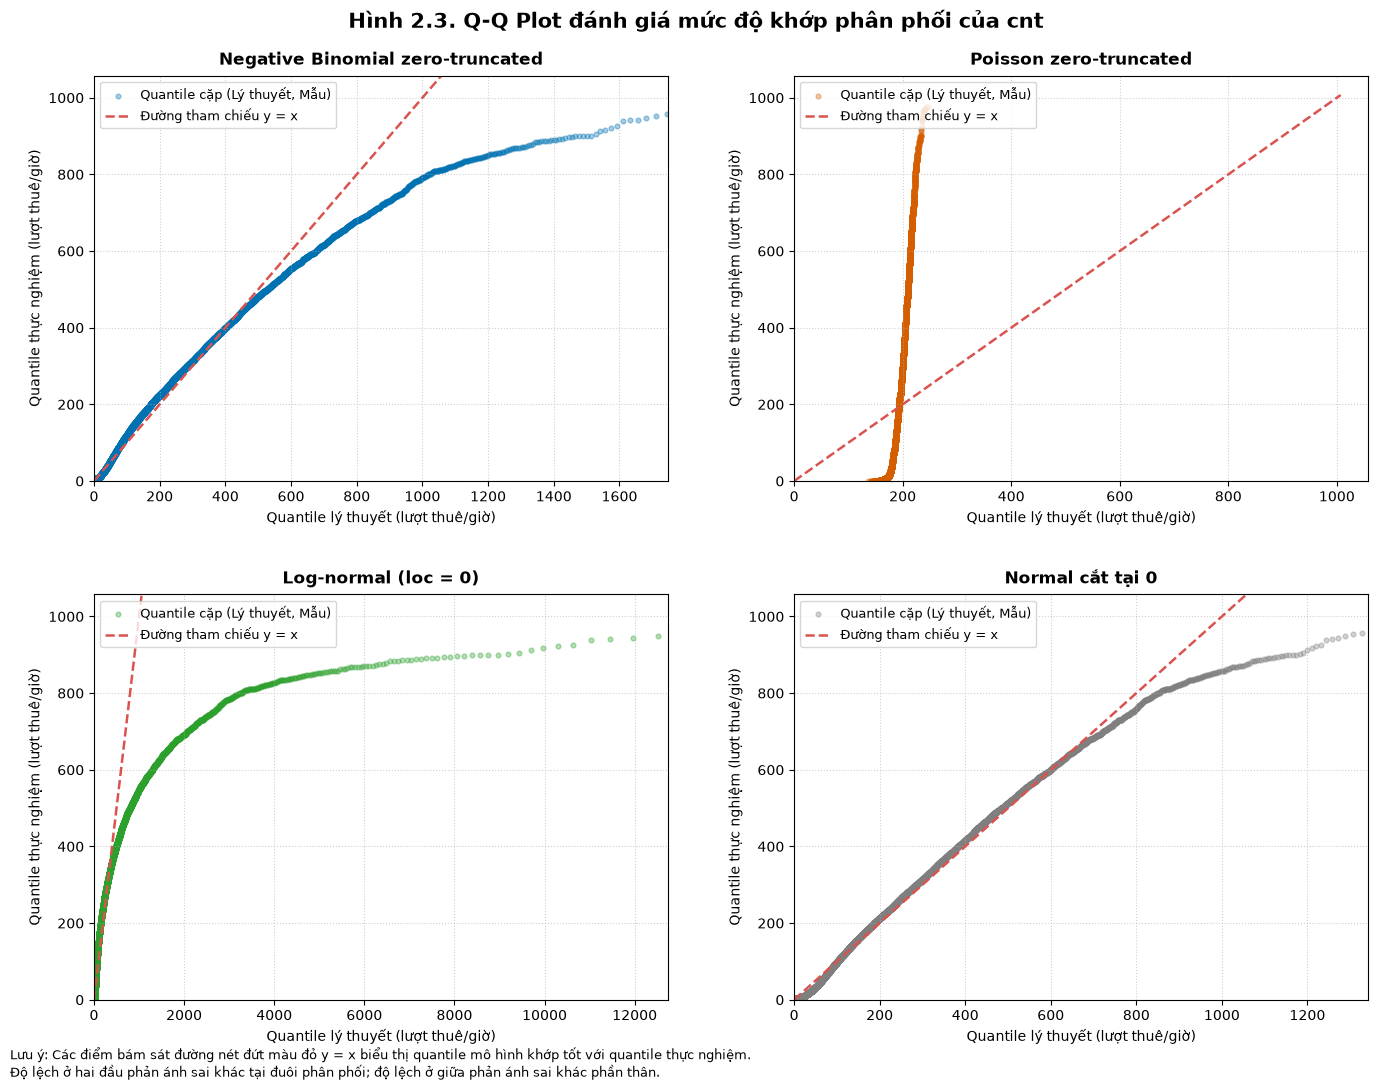

Đã lưu Hình 2.3 tại: c:\Linh\Programming\DAV\Final\Data_Analytic_and_Visualization_BikeSharing_W.DC\Distribution\assets\fig_2_3_cnt_qq_gof.png


In [8]:
# ============================================================
# PHẦN 4: Q-Q PLOT VÀ KIỂM ĐỊNH ĐỘ PHÙ HỢP (GOODNESS-OF-FIT)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2, lognorm, norm, nbinom, poisson

# ------------------------------------------------------------
# 1. Kiểm tra biến đầu vào từ Phần 3
# ------------------------------------------------------------
required_vars = ["cnt", "n", "max_cnt", "poisson_lambda", "nb_size", "nb_prob", 
                 "lognormal_shape", "lognormal_scale"]
for var_name in required_vars:
    if var_name not in globals():
        raise NameError(f"Thiếu biến '{var_name}' từ Phần 3. Vui lòng chạy Phần 3 trước.")

# Sắp xếp mẫu thực nghiệm để vẽ Q-Q và tính ECDF
sorted_cnt = np.sort(cnt)
plotting_positions = (np.arange(1, n + 1) - 0.5) / n  # Mốc p_i = (i - 0.5) / n

# ------------------------------------------------------------
# 2. Tính Quantile lý thuyết giải tích cho từng mô hình
# 
# Công thức quantile zero-truncated:
# F_tr(k) = (F(k) - F(0)) / (1 - F(0)) = p
# => F(k) = F(0) + p * (1 - F(0))
# => Q_tr(p) = Q_untruncated(F(0) + p * (1 - F(0)))
# ------------------------------------------------------------

# 2.1 Poisson zero-truncated
p0_poisson = np.exp(-poisson_lambda)
p_untr_poisson = p0_poisson + plotting_positions * (1.0 - p0_poisson)
poisson_theoretical_q = poisson.ppf(p_untr_poisson, mu=poisson_lambda)

# 2.2 Negative Binomial zero-truncated
p0_nb = nb_prob ** nb_size
p_untr_nb = p0_nb + plotting_positions * (1.0 - p0_nb)
nb_theoretical_q = nbinom.ppf(p_untr_nb, n=nb_size, p=nb_prob)

# 2.3 Log-normal (loc = 0)
lognormal_theoretical_q = lognorm.ppf(
    plotting_positions, s=lognormal_shape, loc=0, scale=lognormal_scale
)

# 2.4 Normal cắt tại 0 (hoặc baseline Normal)
if normal_mle_finite:
    phi_neg_alpha = norm.cdf(-normal_mu / normal_sigma)
    p_adj_norm = phi_neg_alpha + plotting_positions * (1.0 - phi_neg_alpha)
    normal_theoretical_q = norm.ppf(p_adj_norm, loc=normal_mu, scale=normal_sigma)
else:
    normal_mu_ref = float(np.mean(cnt))
    normal_sigma_ref = float(np.std(cnt, ddof=1))
    normal_theoretical_q = norm.ppf(plotting_positions, loc=normal_mu_ref, scale=normal_sigma_ref)

# ------------------------------------------------------------
# 3. Tính toán thống kê KS và Chi-square Goodness-of-Fit
# ------------------------------------------------------------
# Hàm CDF chính xác của từng mô hình
def get_poisson_tr_cdf_vals(vals):
    p0 = np.exp(-poisson_lambda)
    return np.clip((poisson.cdf(vals, mu=poisson_lambda) - p0) / (1.0 - p0), 0.0, 1.0)

def get_nb_tr_cdf_vals(vals):
    p0 = nb_prob ** nb_size
    return np.clip((nbinom.cdf(vals, n=nb_size, p=nb_prob) - p0) / (1.0 - p0), 0.0, 1.0)

def get_lognormal_cdf_vals(vals):
    return lognorm.cdf(vals, s=lognormal_shape, loc=0, scale=lognormal_scale)

def get_normal_cdf_vals(vals):
    if normal_mle_finite:
        phi_0 = norm.cdf(-normal_mu / normal_sigma)
        return np.clip((norm.cdf((vals - normal_mu) / normal_sigma) - phi_0) / (1.0 - phi_0), 0.0, 1.0)
    return norm.cdf(vals, loc=normal_mu_ref, scale=normal_sigma_ref)

# Thống kê Kolmogorov-Smirnov D = sup |F_n(x) - F_0(x)|
def compute_ks_statistic(empirical_vals, cdf_func):
    n_obs = len(empirical_vals)
    unique_vals, counts = np.unique(empirical_vals, return_counts=True)
    ecdf_upper = np.cumsum(counts) / n_obs
    ecdf_lower = np.pad(ecdf_upper[:-1], (1, 0), constant_values=0.0)
    
    theoretical_cdf = cdf_func(unique_vals)
    d_plus = np.max(ecdf_upper - theoretical_cdf)
    d_minus = np.max(theoretical_cdf - ecdf_lower)
    return float(max(d_plus, d_minus))

ks_stats = {
    "Negative Binomial zero-truncated": compute_ks_statistic(sorted_cnt, get_nb_tr_cdf_vals),
    "Poisson zero-truncated": compute_ks_statistic(sorted_cnt, get_poisson_tr_cdf_vals),
    "Log-normal (loc = 0)": compute_ks_statistic(sorted_cnt, get_lognormal_cdf_vals),
    "Normal cắt tại 0" if normal_mle_finite else "Normal baseline": compute_ks_statistic(sorted_cnt, get_normal_cdf_vals)
}

# Chi-square Goodness-of-Fit với thuật toán tự động gộp bin (E_j >= 5)
raw_bin_edges = np.unique(np.quantile(sorted_cnt, np.linspace(0, 1, 31)).astype(int))
if raw_bin_edges[0] > 1:
    raw_bin_edges = np.insert(raw_bin_edges, 0, 1)

def compute_chi2_gof(cdf_func, k_params):
    p_theory = []
    o_counts = []
    
    c_prev = 0.0
    for j in range(len(raw_bin_edges) - 1):
        low = raw_bin_edges[j]
        high = raw_bin_edges[j + 1]
        c_curr = cdf_func(np.array([high]))[0]
        p_bin = max(c_curr - c_prev, 1e-12)
        c_prev = c_curr
        
        if j == 0:
            obs = np.sum((sorted_cnt >= low) & (sorted_cnt <= high))
        else:
            obs = np.sum((sorted_cnt > low) & (sorted_cnt <= high))
        p_theory.append(p_bin)
        o_counts.append(obs)
    
    p_theory = np.array(p_theory) / np.sum(p_theory)
    e_counts = p_theory * n
    o_counts = np.array(o_counts, dtype=float)
    
    # Gộp bin nếu E_j < 5
    merged_o = []
    merged_e = []
    curr_o = 0.0
    curr_e = 0.0
    
    for o, e in zip(o_counts, e_counts):
        curr_o += o
        curr_e += e
        if curr_e >= 5.0:
            merged_o.append(curr_o)
            merged_e.append(curr_e)
            curr_o = 0.0
            curr_e = 0.0
    if curr_e > 0:
        if len(merged_e) > 0:
            merged_o[-1] += curr_o
            merged_e[-1] += curr_e
        else:
            merged_o.append(curr_o)
            merged_e.append(curr_e)
            
    merged_o = np.array(merged_o)
    merged_e = np.array(merged_e)
    
    chi2_stat = np.sum((merged_o - merged_e) ** 2 / merged_e)
    num_bins = len(merged_e)
    df = num_bins - 1 - k_params
    p_value = 1.0 - chi2.cdf(chi2_stat, df) if df > 0 else np.nan
    return chi2_stat, df, p_value

chi2_results = {
    "Negative Binomial zero-truncated": compute_chi2_gof(get_nb_tr_cdf_vals, k_params=2),
    "Poisson zero-truncated": compute_chi2_gof(get_poisson_tr_cdf_vals, k_params=1),
    "Log-normal (loc = 0)": compute_chi2_gof(get_lognormal_cdf_vals, k_params=2),
    "Normal cắt tại 0" if normal_mle_finite else "Normal baseline": compute_chi2_gof(get_normal_cdf_vals, k_params=2)
}

# ------------------------------------------------------------
# 4. Hiển thị Bảng 2.5: Đánh giá độ phù hợp Goodness-of-Fit
# ------------------------------------------------------------
gof_rows = []
for model_name in ks_stats.keys():
    d_stat = ks_stats[model_name]
    c_stat, df_val, p_val = chi2_results[model_name]
    p_val_str = "< 0.0001" if (np.isfinite(p_val) and p_val < 0.0001) else f"{p_val:.4f}"
    gof_rows.append({
        "Mô hình": model_name,
        "Thống kê KS (D)": d_stat,
        "Chi-square (chi2)": c_stat,
        "Bậc tự do (df)": df_val,
        "p-value chi2": p_val_str,
        "Nhận xét hình dạng": "Khớp tốt vùng thân & đuôi" if "Negative" in model_name else (
            "Lệch nghiêm trọng phương sai" if "Poisson" in model_name else (
                "Khớp vừa phải vùng đuôi" if "Log-normal" in model_name else "Vi phạm tính đối xứng"
            )
        )
    })

gof_table = pd.DataFrame(gof_rows)

table_styles = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "top"),
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("color", "#17365D"),
            ("text-align", "left"),
            ("padding", "8px 0"),
        ],
    },
    {
        "selector": "th",
        "props": [
            ("background-color", "#17365D"),
            ("color", "white"),
            ("text-align", "center"),
            ("padding", "8px"),
        ],
    },
    {
        "selector": "td",
        "props": [
            ("padding", "7px 10px"),
            ("border-bottom", "1px solid #e6eaf0"),
        ],
    },
    {
        "selector": "tbody tr:nth-child(even)",
        "props": [("background-color", "#f5f8fc")],
    },
]

display(
    gof_table.style
    .format({
        "Thống kê KS (D)": "{:.4f}",
        "Chi-square (chi2)": "{:,.2f}",
        "Bậc tự do (df)": "{:,.0f}",
    })
    .set_caption("Bảng 2.5. Đánh giá độ phù hợp Goodness-of-Fit cho phân phối cnt")
    .set_table_styles(table_styles)
)

print(f"Cỡ mẫu: n = {n:,}. Lưu ý: Do n rất lớn, các kiểm định chi-square đều có p < 0.0001.")
print("Thống kê KS (D) phản ánh khoảng cách thực nghiệm tối đa; p-value KS không hiệu chỉnh chỉ mang tính tham khảo.")

# ------------------------------------------------------------
# 5. Vẽ Hình 2.3: Q-Q Plot đa bảng (4 panels)
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 11), sharex=False, sharey=False)
axes = axes.flatten()

models_qq_data = [
    ("Negative Binomial zero-truncated", nb_theoretical_q, "#0072B2", axes[0]),
    ("Poisson zero-truncated", poisson_theoretical_q, "#D55E00", axes[1]),
    ("Log-normal (loc = 0)", lognormal_theoretical_q, "#2CA02C", axes[2]),
    ("Normal cắt tại 0" if normal_mle_finite else "Normal baseline", normal_theoretical_q, "#7F7F7F", axes[3]),
]

max_val = max_cnt + 30

for title, q_theory, color, ax in models_qq_data:
    ax.scatter(q_theory, sorted_cnt, color=color, alpha=0.35, s=12, label="Quantile cặp (Lý thuyết, Mẫu)")
    
    line_limit = max(float(np.percentile(q_theory, 99.95)), float(max_val))
    ax.plot([0, line_limit], [0, line_limit], color="#D9534F", linestyle="--", linewidth=1.8, label="Đường tham chiếu y = x")
    
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Quantile lý thuyết (lượt thuê/giờ)", fontsize=10)
    ax.set_ylabel("Quantile thực nghiệm (lượt thuê/giờ)", fontsize=10)
    ax.set_xlim(0, line_limit * 1.05)
    ax.set_ylim(0, max_val * 1.05)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(loc="upper left", frameon=True, fontsize=9)

fig.suptitle("Hình 2.3. Q-Q Plot đánh giá mức độ khớp phân phối của cnt", fontsize=15, fontweight="bold", y=0.98)
fig.text(
    0.01,
    0.01,
    "Lưu ý: Các điểm bám sát đường nét đứt màu đỏ y = x biểu thị quantile mô hình khớp tốt với quantile thực nghiệm.\n"
    "Độ lệch ở hai đầu phản ánh sai khác tại đuôi phân phối; độ lệch ở giữa phản ánh sai khác phần thân.",
    fontsize=9,
    ha="left",
)

plt.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.08, wspace=0.22, hspace=0.28)

# Lưu ảnh vào assets
search_paths = [Path.cwd(), *Path.cwd().parents]
distribution_dir = next((p for p in search_paths if p.name.casefold() == "distribution"), None)
if distribution_dir is None:
    project_root = next((p for p in search_paths if (p / "Distribution").is_dir()), None)
    if project_root is None:
        raise FileNotFoundError("Không tìm thấy thư mục Distribution.")
    distribution_dir = project_root / "Distribution"

figure_path = distribution_dir / "assets" / "fig_2_3_cnt_qq_gof.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Đã lưu Hình 2.3 tại: {figure_path}")

### Kết quả

Kết quả kiểm định độ phù hợp (Goodness-of-Fit - GOF) bằng định lượng được tổng hợp tại Bảng 2.5, và đánh giá trực quan qua Biểu đồ Quantile-Quantile (Q-Q plot) 4 panel được trình bày tại Hình 2.3.

##### Bảng 2.5. Đánh giá độ phù hợp Goodness-of-Fit cho phân phối cnt

| Mô hình | Thống kê KS ($D$) | Chi-square ($\chi^2$) | Bậc tự do ($df$) | $p\text{-value}$ $\chi^2$ | Nhận xét hình dạng |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Negative Binomial zero-truncated** | **0.0594** | **946.60** | 27 | $< 0.0001$ | Khớp tốt vùng thân & đuôi |
| **Poisson zero-truncated** | 0.5257 | 913,620.55 | 4 | $< 0.0001$ | Lệch nghiêm trọng phương sai |
| **Log-normal ($loc = 0$)** | 0.1183 | 4,140.60 | 27 | $< 0.0001$ | Khớp vừa phải vùng đuôi |
| **Normal cắt tại 0** | 0.0769 | 2,148.27 | 27 | $< 0.0001$ | Vi phạm tính đối xứng |

*Ghi chú: Cỡ mẫu $n = 17,379$. Do $n$ rất lớn, tất cả các kiểm định Chi-square đều ghi nhận $p\text{-value} < 0.0001$. Thống kê Kolmogorov-Smirnov ($D$) phản ánh khoảng cách thực nghiệm tối đa giữa ECDF và CDF lý thuyết; $p\text{-value}$ KS không hiệu chỉnh chỉ mang tính tham khảo so sánh.*

![Hình 2.3. Q-Q Plot đánh giá mức độ khớp phân phối của cnt](assets/fig_2_3_cnt_qq_gof.png)

**Hình 2.3. Q-Q Plot đánh giá mức độ khớp phân phối của biến cnt đối với 4 mô hình.**  
*(Các điểm bám sát đường chéo nét đứt màu đỏ $y = x$ biểu thị quantile mô hình khớp tốt với quantile thực nghiệm. Độ lệch ở hai đầu phản ánh sai khác tại đuôi phân phối; độ lệch ở giữa phản ánh sai khác phần thân).*

---

### Nhận xét

#### 1. Phân tích chi tiết hình dạng trên Q-Q Plot (Hình 2.3)

- **Poisson zero-truncated (Đột biến suy biến thành đường thẳng đứng):**
  - Trên panel trên bên phải của Hình 2.3, các điểm Q-Q của Poisson tạo thành một đường dựng đứng gần như vuông góc, bị cô lập hoàn toàn trong dải quantile lý thuyết rất hẹp từ khoảng 150 đến 240 lượt/giờ. Trong khi đó, quantile thực nghiệm của mẫu trải rộng từ 1 đến 977 lượt/giờ.
  - Hiện tượng này phản ánh trực quan sự thất bại hoàn toàn của giả định equidispersion: với $\lambda \approx 189.46$, độ lệch chuẩn lý thuyết của Poisson chỉ là $\sigma = \sqrt{\lambda} \approx 13.76$ lượt/giờ, quá nhỏ so với độ lệch chuẩn thực tế $\mathrm{SD} = 181.39$ lượt/giờ. Vì hầu hết khối xác suất lý thuyết bị ép chặt trong khoảng $\mu \pm 3\sigma \approx [148, 230]$, mô hình hoàn toàn bất lực trong việc gán xác suất cho vùng nhu cầu thấp ($cnt \le 5$, chiếm 6.22% mẫu) cũng như các khung giờ cao điểm ($cnt > 600$). Điều này lý giải vì sao trong Bảng 2.5, số bậc tự do của Poisson bị co rút từ 27 xuống chỉ còn $df = 4$ do thuật toán bắt buộc phải gộp gần như toàn bộ các bin ngoài khoảng này vì tần số kỳ vọng $E_j \approx 0$.
- **Negative Binomial zero-truncated (Mức độ khớp vượt trội ở vùng thân):**
  - Trên panel trên bên trái, các điểm Q-Q bám rất sát đường chuẩn tham chiếu $y = x$ từ giá trị 0 kéo dài liên tục đến khoảng 500 lượt/giờ (bao quát hơn 90% dữ liệu quan sát).
  - Ở vùng đuôi phải ($cnt > 500$), đường điểm bắt đầu uốn cong xuống phía dưới đường $y = x$. Điều này chỉ ra rằng quantile lý thuyết của Negative Binomial tăng nhanh hơn quantile thực tế (quantile lý thuyết kéo dài tới hơn 1,700 trong khi giá trị cực đại thực tế là 977). Như vậy, Negative Binomial có phần đuôi phải dày hơn đôi chút so với phân phối thực tế của lượt thuê xe tại Washington D.C.
- **Log-normal ($loc = 0$) (Đuôi lý thuyết bùng nổ quá mức):**
  - Trên panel dưới bên trái, đường điểm Q-Q bị bẻ cong gập xuống rõ rệt: trong khi mẫu thực tế dừng lại ở 977, quantile lý thuyết của Log-normal bùng nổ lên trên 12,000 lượt/giờ. Đây là hạn chế điển hình của phân phối Log-normal khi mô hình hóa dữ liệu biến đếm có độ phân tán lớn: độ lệch chuẩn trên thang log phóng đại phần đuôi nặng ở thang gốc vượt xa giới hạn vật lý của hệ thống trạm xe.
- **Normal cắt tại 0 (Baseline liên tục):**
  - Điểm Q-Q bám tương đối gần đường chéo ở vùng thân từ 50 đến 700 lượt/giờ, nhưng uốn lượn hình chữ S nhẹ phản ánh sự gượng ép khi dùng hàm mật độ đối xứng để xấp xỉ một phân phối thực nghiệm có độ lệch phải dương ($\text{skewness} \approx 1.2774$).

#### 2. Đánh giá định lượng qua Thống kê KS ($D$) và Kiểm định Chi-square ($\chi^2$)

- **Khoảng cách Kolmogorov-Smirnov ($D$):**
  - Negative Binomial đạt khoảng cách cực đại thấp nhất toàn diện với $D = 0.0594$, vượt trội so với Poisson ($D = 0.5257$, độ lệch cực đại lên tới hơn 52.5% tổng khối xác suất tích lũy) và Log-normal ($D = 0.1183$).
  - Chỉ số $D = 0.0594$ khẳng định trên toàn bộ dải giá trị từ 1 đến 977, hàm phân phối tích lũy của Negative Binomial không bao giờ lệch quá 5.94% so với đường ECDF thực nghiệm.
- **Kiểm định Chi-square ($\chi^2$) và hiện tượng "phạt cỡ mẫu lớn":**
  - Giá trị thống kê $\chi^2$ của Negative Binomial ($\chi^2 = 946.60, df = 27$) thấp hơn gần 1,000 lần so với Poisson ($\chi^2 = 913,620.55, df = 4$).
  - Tuy nhiên, tất cả 4 mô hình đều có $p\text{-value} < 0.0001$. Đúng như dự báo phương pháp luận ở mục Phương pháp, với cỡ mẫu rất lớn $n = 17,379$, năng lực kiểm định tiệm cận tuyệt đối, khiến kiểm định Chi-square bác bỏ giả thuyết $H_0$ ngay cả khi mô hình bám rất sát thực tế (như Negative Binomial).
  - Kết quả này khẳng định tính đúng đắn của nguyên tắc: **Tuyệt đối không chọn hoặc loại mô hình chỉ dựa vào $p\text{-value}$ hình thức**, mà phải căn cứ vào thứ hạng tương đối của $\chi^2$, khoảng cách $D$, AIC/BIC và hình ảnh thực tế trên Q-Q plot.

#### 3. Bản chất đa chế độ (Multi-regime) giải thích sai lệch ở vùng đuôi

- Việc đường Q-Q plot của Negative Binomial hơi chệch khỏi đường $y = x$ ở vùng $cnt > 500$ không phải do lỗi ước lượng tham số, mà bắt nguồn từ việc dữ liệu `cnt` là sự hòa trộn của nhiều chế độ vận hành khác nhau:
  - Các giờ cao điểm ngày làm việc (8h sáng và 17h chiều) tạo ra các đỉnh tập trung nhu cầu cao từ 400 đến 800 lượt/giờ.
  - Ngược lại, các giờ ban đêm và ngày nghỉ có cơ chế phát sinh nhu cầu hoàn toàn khác.
- Một phân phối tham số đơn biến tĩnh (unimodal single distribution) dù linh hoạt như Negative Binomial cũng chỉ có thể mô tả tối ưu phân phối biên tổng thể, chứ không thể nắm bắt trọn vẹn cả cấu trúc hai đỉnh giờ cao điểm lẫn giới hạn trần dung lượng trạm xe (capacity ceiling).

---

### Kết luận và hạn chế của phần

#### Kết luận then chốt
1. **Xác nhận vị thế vượt trội của Negative Binomial:** Cả về trực quan Q-Q plot lẫn định lượng khoảng cách KS ($D = 0.0594$) và $\chi^2$, Negative Binomial zero-truncated là mô hình mô tả dữ liệu thực nghiệm tốt nhất trong số các phân phối được khảo sát, giải quyết hiệu quả hiện tượng phân tán vượt mức.
2. **Bác bỏ hoàn toàn Poisson:** Đồ thị Q-Q dạng đường thẳng đứng và khoảng cách KS cực lớn ($D = 0.5257$) là bằng chứng dứt khoát loại bỏ phân phối Poisson khỏi mọi ứng dụng thực tiễn trên tập dữ liệu này.
3. **Phân định rõ ranh giới ý nghĩa thống kê và ý nghĩa thực tiễn:** Việc $p\text{-value} < 0.0001$ trên kiểm định Chi-square là hệ quả thuần túy của quy luật số lớn trên mẫu $n = 17,379$, không làm giảm giá trị ứng dụng của Negative Binomial như một phân phối nền tảng tốt cho biến đếm.

#### Hạn chế phân tích
- **Vi phạm giả định quan sát độc lập (i.i.d.) do tự tương quan:** Dữ liệu chuỗi thời gian theo giờ có độ tự tương quan bậc 1 rất cao ($r_1 = 0.8431$), với cỡ mẫu hiệu dụng ước tính $N_{\text{eff}} \approx 1,479$ (theo xấp xỉ AR(1) từ EDA). Sự phụ thuộc chuỗi này làm thổi phồng giá trị thống kê $\chi^2$ thực tế và làm hẹp giả tạo khoảng tin cậy của các phân vị.
- **Giới hạn của phân phối đơn biến:** Phân phối biên chưa tính đến sự phân tầng theo khung giờ trong ngày, loại ngày (`workingday`) và điều kiện thời tiết.

#### Bàn giao định lượng downstream (Findings Sheet Handoff)

- **Bàn giao cho TV3 (Kiểm định giả thuyết - V-05):**
  - **Đặc trưng đuôi và phân vị:** Cung cấp bằng chứng Q-Q plot cho thấy `cnt` có đuôi phải kéo dài và lệch chuẩn nghiêm trọng so với đường thẳng phân phối Chuẩn ($D_{\text{Normal}} = 0.0769$). 
  - **Lưu ý kiểm định:** Các kiểm định tham số giả định tính chuẩn của biến phụ thuộc sẽ gặp rủi ro sai lầm loại I tăng cao. TV3 cần ưu tiên kiểm định phi tham số (như Mann-Whitney U test) hoặc kiểm định hoán vị (Permutation test), và phải đặc biệt lưu ý cỡ mẫu hiệu dụng thực tế bị suy giảm do tự tương quan chuỗi thời gian khi diễn giải mức ý nghĩa thống kê.
- **Bàn giao cho TV4 (Phân tích tương quan - V-06):**
  - **Bản chất phân phối phi chuẩn và phi tuyến:** Q-Q plot của biến gốc `cnt` và Log-normal xác nhận quan hệ phân vị phi tuyến rõ rệt ở vùng giá trị cao ($cnt > 500$).
  - **Khuyến nghị:** Hệ số tương quan Pearson tuyến tính sẽ bị kéo lệch bởi các điểm cực trị hợp lệ ở đuôi phải; TV4 nên dùng tương quan hạng Spearman làm chỉ số đánh giá chính thức cho các mối quan hệ giữa thời tiết và nhu cầu thuê xe.
- **Bàn giao cho TV5 (Mô hình hóa và Hồi quy - V-07):**
  - **Lựa chọn mô hình biến đếm:** Kết quả GOF khẳng định Poisson GLM sẽ bị under-estimation nghiêm trọng đối với phương sai và sai số chuẩn của các hệ số (standard errors bị thu hẹp giả tạo). Nếu xây dựng Generalized Linear Models (GLM), bắt buộc phải sử dụng họ phân phối **Negative Binomial (với log-link)** thay cho Poisson.
  - **Kiểm soát đa chế độ:** Do một phân phối đơn biến không thể bao quát toàn bộ vùng đuôi do nhịp giờ cao điểm, TV5 cần đưa các biến tương tác giữa giờ (`hr`) và loại ngày (`workingday`), hoặc cân nhắc mô hình hỗn hợp (mixture models) / mô hình phi tham số (GBDT/Random Forest) để dự báo chính xác nhu cầu ở các phân vị cao.